# **Importing Necessary Libraries and Dependencies**

In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.signal import butter, filtfilt, find_peaks
from scipy.stats import skew, kurtosis, entropy
from numpy.fft import fft
from tqdm import tqdm
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, VotingClassifier
import warnings
warnings.filterwarnings("ignore")

# **Importing the Dataset Folder**

In [2]:
# Path to my EARBUDS folder
data_folder = "/kaggle/input/earbuds/EARBUDS"

# Listing all CSV files
csv_files = [f for f in os.listdir(data_folder) if f.endswith('.csv')]

# Extracting relevant info from filenames
data = []
for filename in csv_files:
    parts = filename.split('-')
    person_id = int(parts[0])
    action = parts[1]
    side = parts[-1].replace('.csv', '')
    label = f"{action}-{side}"
    
    data.append({
        'filename': filename,
        'person_id': person_id,
        'action': label,
        'filepath': os.path.join(data_folder, filename)
    })

# Creating DataFrame
df_index = pd.DataFrame(data)
df_index.head()

,filename,person_id,action,filepath
0,10-running-imu-left.csv,10,running-left,/kaggle/input/earbuds/EARBUDS/10-running-imu-l...
1,8-shake-imu-left.csv,8,shake-left,/kaggle/input/earbuds/EARBUDS/8-shake-imu-left...
2,17-swallowing-imu-right.csv,17,swallowing-right,/kaggle/input/earbuds/EARBUDS/17-swallowing-im...
3,15-chewing-imu-left.csv,15,chewing-left,/kaggle/input/earbuds/EARBUDS/15-chewing-imu-l...
4,13-still-imu-left.csv,13,still-left,/kaggle/input/earbuds/EARBUDS/13-still-imu-lef...


In [3]:
# Counting the number of files per action
action_counts = df_index['action'].value_counts()

# Keeping only actions with more than 5 files
valid_actions = action_counts[action_counts >= 5].index

# Filtering the DataFrame
df_index_filtered = df_index[df_index['action'].isin(valid_actions)].reset_index(drop=True)

print(f"Remaining Actions: {df_index_filtered['action'].nunique()}")
print("Actions kept:\n", df_index_filtered['action'].value_counts())

Remaining Actions: 30
Actions kept:
 action
wink-right          59
wink-left           59
eyes-left           58
brow-right          58
eyes-right          58
brow-left           58
running-right       31
running-left        31
speaking-left       29
still-left          29
shake-left          29
still-right         29
chewing-left        29
swallowing-right    29
swallowing-left     29
shake-right         29
lip-left            29
chin-left           29
nod-right           29
lip-right           29
tilt-left           29
nod-left            29
speaking-right      29
walking-left        29
chin-right          29
tilt-right          29
walking-right       29
chewing-right       29
mouth-left          28
mouth-right         28
Name: count, dtype: int64


# **Feature Engineering**

In [4]:
# Butterworth filter
def butterworth_filter(data, cutoff=3, fs=50, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

# FFT
def compute_fft(signal):
    fft_vals = np.abs(fft(signal))
    return fft_vals[:len(fft_vals)//2]

# Derivative (jerk)
def compute_jerk(signal):
    return np.diff(signal)

# Vector magnitude
def vector_magnitude(x, y, z):
    return np.sqrt(x**2 + y**2 + z**2)

# Cross-correlation between two signals
def cross_corr(a, b):
    return np.correlate(a - np.mean(a), b - np.mean(b), mode='valid')[0]

# Extracting features from one signal
def extract_signal_features(signal, signal_name):
    features = {}
    fft_vals = compute_fft(signal)
    jerk = compute_jerk(signal)
    
    # Time domain
    features[f'{signal_name}_mean'] = np.mean(signal)
    features[f'{signal_name}_std'] = np.std(signal)
    features[f'{signal_name}_max'] = np.max(signal)
    features[f'{signal_name}_min'] = np.min(signal)
    features[f'{signal_name}_range'] = np.ptp(signal)
    features[f'{signal_name}_median'] = np.median(signal)
    features[f'{signal_name}_skew'] = skew(signal)
    features[f'{signal_name}_kurtosis'] = kurtosis(signal)
    features[f'{signal_name}_iqr'] = np.percentile(signal, 75) - np.percentile(signal, 25)
    features[f'{signal_name}_energy'] = np.sum(signal**2)
    
    # Frequency domain
    features[f'{signal_name}_fft_energy'] = np.sum(fft_vals**2)
    features[f'{signal_name}_fft_peak'] = np.argmax(fft_vals)
    features[f'{signal_name}_fft_entropy'] = entropy(fft_vals + 1e-8)  # avoid log(0)
    
    # Jerk
    features[f'{signal_name}_jerk_mean'] = np.mean(jerk)
    features[f'{signal_name}_jerk_max'] = np.max(jerk)
    features[f'{signal_name}_jerk_std'] = np.std(jerk)
    
    # Peaks and troughs
    peaks, _ = find_peaks(signal)
    troughs, _ = find_peaks(-signal)
    features[f'{signal_name}_num_peaks'] = len(peaks)
    features[f'{signal_name}_num_troughs'] = len(troughs)
    features[f'{signal_name}_peak_trough_diff'] = len(peaks) - len(troughs)
    
    # Zero-crossing
    zero_crossings = np.where(np.diff(np.sign(signal)))[0]
    features[f'{signal_name}_zero_crossings'] = len(zero_crossings)
    
    return features

# Main feature extraction
def extract_all_features(df):
    feats = {}

    # Applying Butterworth and extracting features per column
    signals = {}
    for col in ['ax', 'ay', 'az', 'gx', 'gy', 'gz']:
        filtered = butterworth_filter(df[col].values)
        signals[col] = filtered
        feats.update(extract_signal_features(filtered, col))

    # Magnitude features
    acc_mag = vector_magnitude(signals['ax'], signals['ay'], signals['az'])
    gyro_mag = vector_magnitude(signals['gx'], signals['gy'], signals['gz'])
    feats.update(extract_signal_features(acc_mag, 'acc_mag'))
    feats.update(extract_signal_features(gyro_mag, 'gyro_mag'))

    # Cross-correlations
    feats['corr_ax_ay'] = cross_corr(signals['ax'], signals['ay'])
    feats['corr_gy_gz'] = cross_corr(signals['gy'], signals['gz'])

    return feats

# Splitting the CSV time series into overlapping windows and extracting features per window
def process_file_windowed(filepath, label, person_id, filename, fs=50, window_sec=4, step_sec=2):
    df = pd.read_csv(filepath)
    window_size = fs * window_sec
    step_size = fs * step_sec
    total_samples = len(df)

    features_list = []

    for start in range(0, total_samples - window_size + 1, step_size):
        end = start + window_size
        window_df = df.iloc[start:end]

        # Skipping windows with NaNs or weird data
        if window_df.isnull().values.any():
            continue

        try:
            features = extract_all_features(window_df)
            features['label'] = label
            features['filename'] = filename
            features['person_id'] = person_id
            features_list.append(features)
        except Exception as e:
            print(f"Skipping window due to error: {e}")
            continue

    return features_list

all_windowed_features = []

for _, row in tqdm(df_index_filtered.iterrows(), total=len(df_index_filtered)):
    feats = process_file_windowed(row['filepath'], row['action'], row['person_id'], row['filename'])
    all_windowed_features.extend(feats)

# Converting to DataFrame
df_features_windowed = pd.DataFrame(all_windowed_features)

100%|██████████| 1048/1048 [42:09<00:00,  2.41s/it]


In [7]:
df_features_windowed.head()

,ax_mean,ax_std,ax_max,ax_min,ax_range,ax_median,ax_skew,ax_kurtosis,ax_iqr,ax_energy,...,gyro_mag_jerk_std,gyro_mag_num_peaks,gyro_mag_num_troughs,gyro_mag_peak_trough_diff,gyro_mag_zero_crossings,corr_ax_ay,corr_gy_gz,label,filename,person_id
0,-2063.073044,2577.967275,2619.874006,-7288.984438,9908.858444,-2098.467403,0.026107,-0.825274,3774.334044,2.180437e+09,...,404.684692,11,10,1,0,3.155367e+09,2.867885e+08,running-left,10-running-imu-left.csv,10
1,-1566.861511,2348.794780,2619.985974,-6313.864353,8933.850327,-1638.637478,0.005037,-1.039453,3812.363100,1.594378e+09,...,406.668603,11,12,-1,0,2.883204e+09,2.055529e+08,running-left,10-running-imu-left.csv,10
2,-1797.458423,2530.922846,2302.644504,-6305.072906,8607.717410,-1601.632353,-0.128667,-1.213750,4309.271583,1.927285e+09,...,403.618858,11,12,-1,0,3.717554e+09,1.013823e+08,running-left,10-running-imu-left.csv,10
3,-1846.224227,2577.819794,2301.772660,-7022.190059,9323.962719,-1447.853124,-0.300061,-1.114903,4341.526238,2.010740e+09,...,383.323187,11,12,-1,0,4.083585e+09,7.133744e+07,running-left,10-running-imu-left.csv,10
4,-1926.176566,2490.109278,1696.622009,-7014.725035,8711.347044,-1507.804834,-0.369918,-1.109537,4199.911731,1.982160e+09,...,319.253344,12,12,0,0,3.480780e+09,6.267424e+07,running-left,10-running-imu-left.csv,10


# **Data Visualisation**

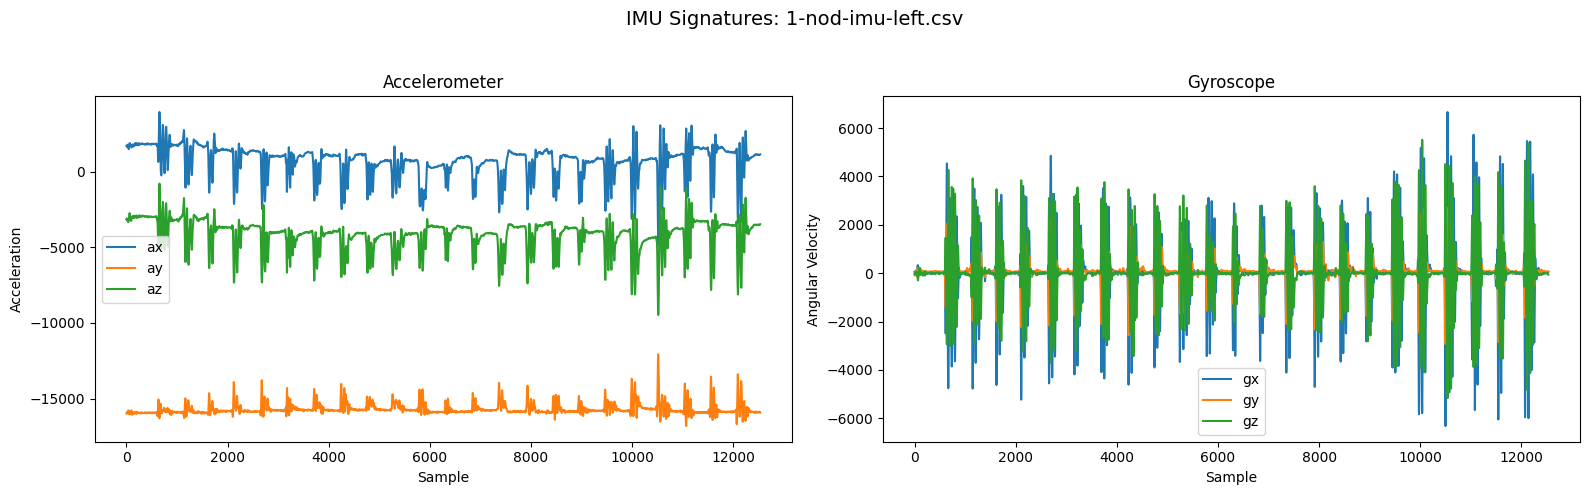

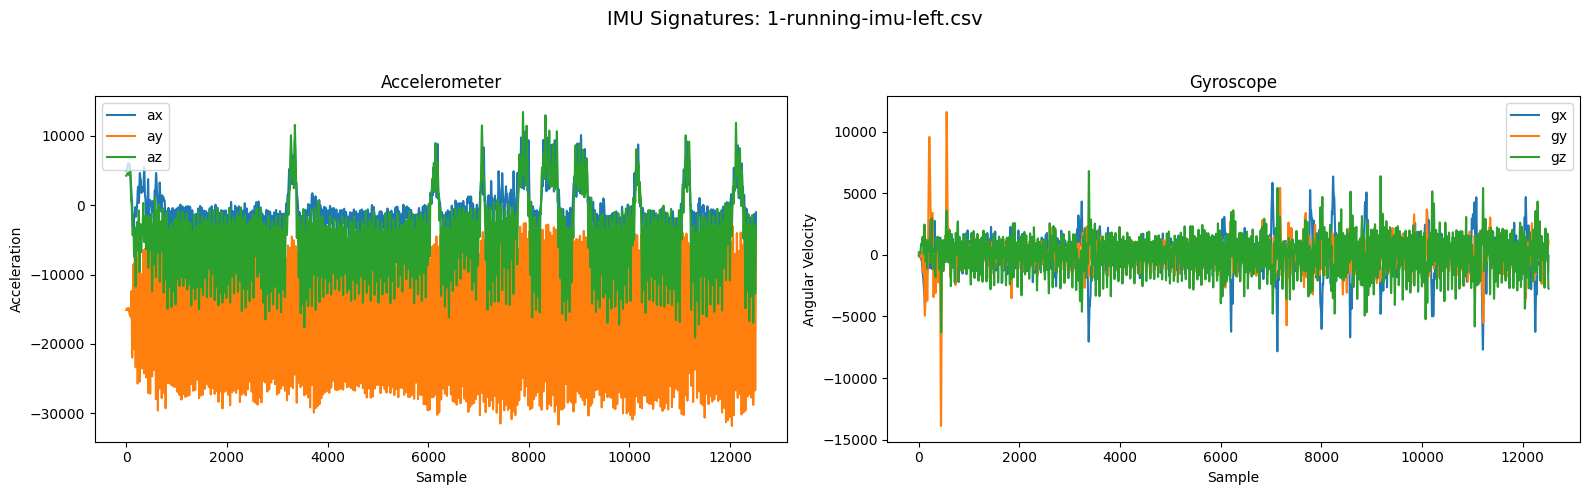

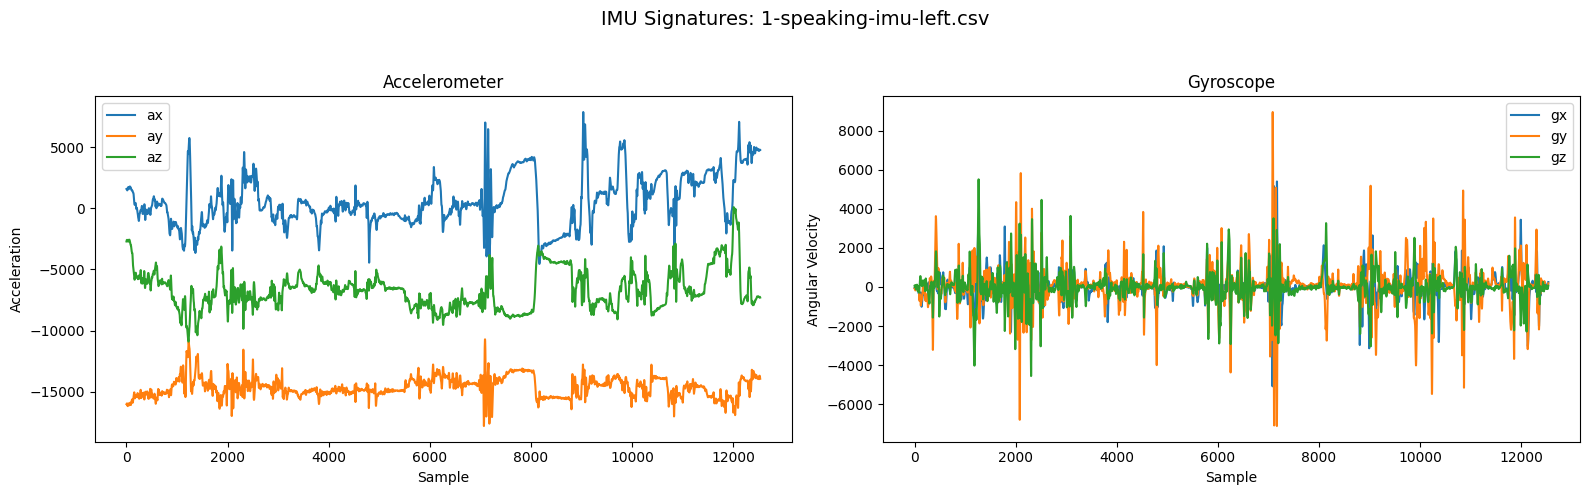

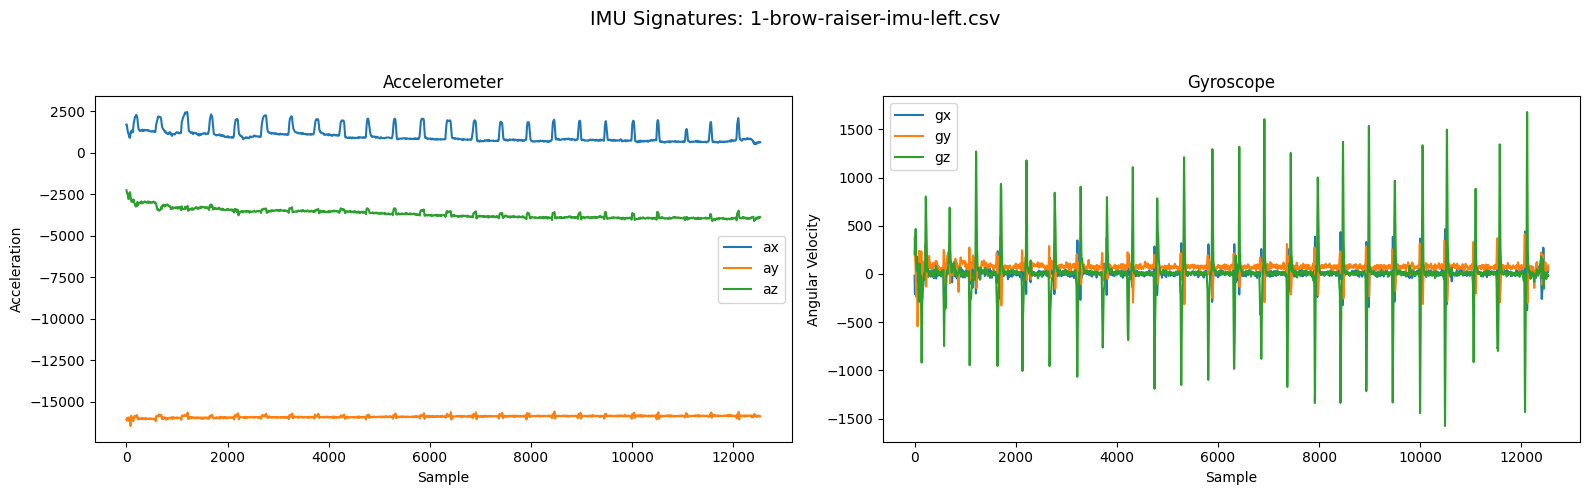

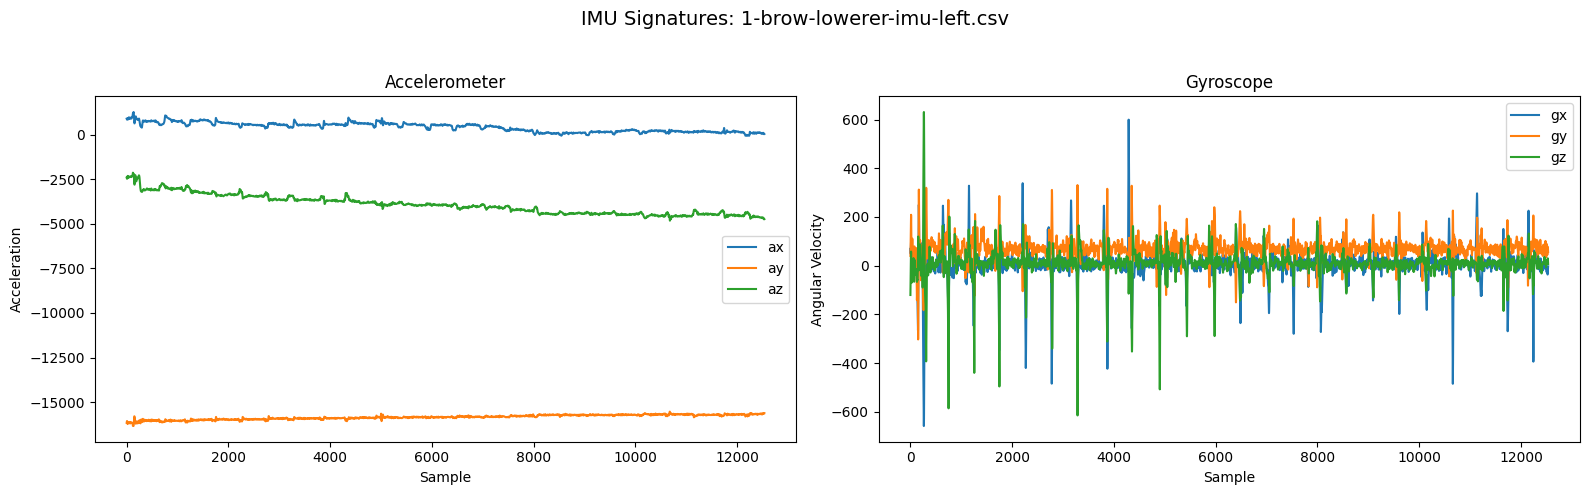

In [7]:
# Few activities to visualise
files = [
    "/kaggle/input/earbuds/EARBUDS/1-nod-imu-left.csv",
    "/kaggle/input/earbuds/EARBUDS/1-running-imu-left.csv",
    "/kaggle/input/earbuds/EARBUDS/1-speaking-imu-left.csv",
    "/kaggle/input/earbuds/EARBUDS/1-brow-raiser-imu-left.csv",
    "/kaggle/input/earbuds/EARBUDS/1-brow-lowerer-imu-left.csv"
]
# Plotting each file
for filepath in files:
    df = pd.read_csv(filepath)
    filename = filepath.split("/")[-1]

    # Filtered signals
    acc_axes = ['ax', 'ay', 'az']
    gyro_axes = ['gx', 'gy', 'gz']

    acc_filtered = {axis: butterworth_filter(df[axis].values) for axis in acc_axes}
    gyro_filtered = {axis: butterworth_filter(df[axis].values) for axis in gyro_axes}

    # Plotting filtered signals only
    plt.figure(figsize=(16, 5))
    plt.suptitle(f"IMU Signatures: {filename}", fontsize=14)

    # Accelerometer
    plt.subplot(1, 2, 1)
    for axis in acc_axes:
        plt.plot(acc_filtered[axis], label=f"{axis}")
    plt.title("Accelerometer")
    plt.xlabel("Sample")
    plt.ylabel("Acceleration")
    plt.legend()

    # Gyroscope
    plt.subplot(1, 2, 2)
    for axis in gyro_axes:
        plt.plot(gyro_filtered[axis], label=f"{axis}")
    plt.title("Gyroscope")
    plt.xlabel("Sample")
    plt.ylabel("Angular Velocity")
    plt.legend()

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

## **Overlay Plot**

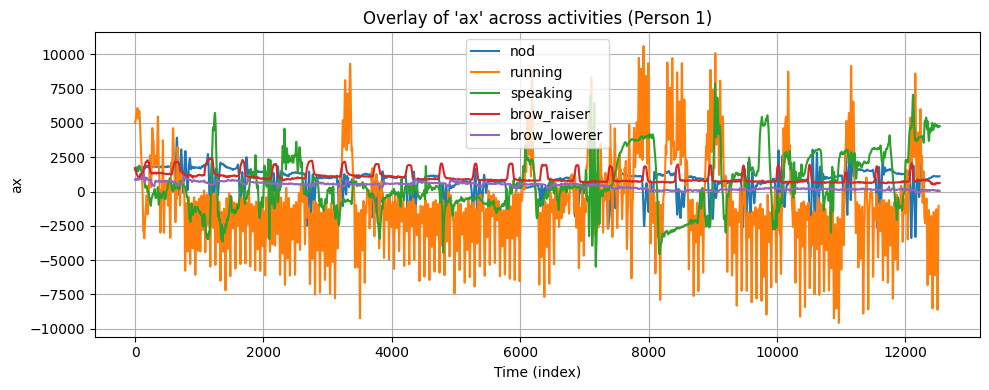

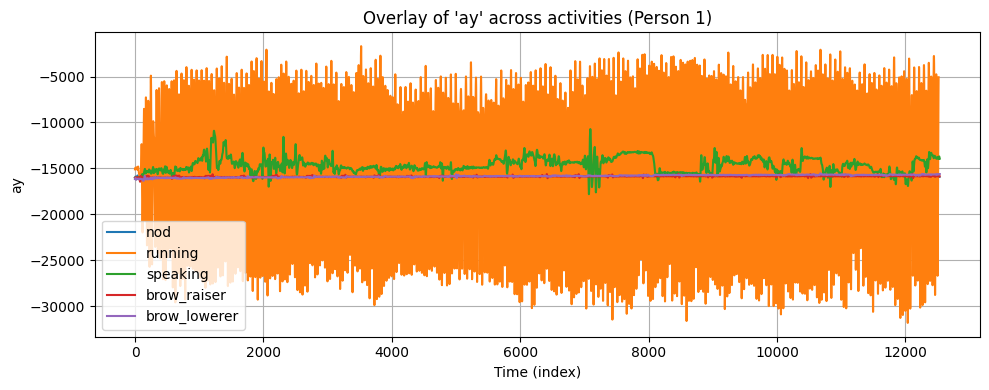

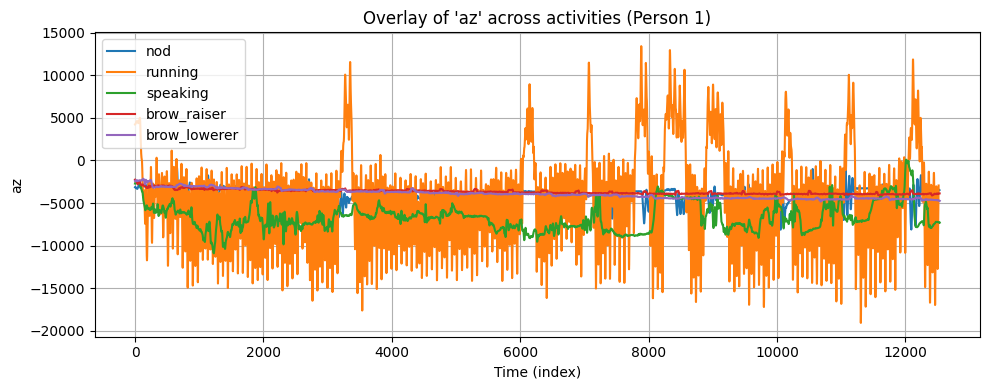

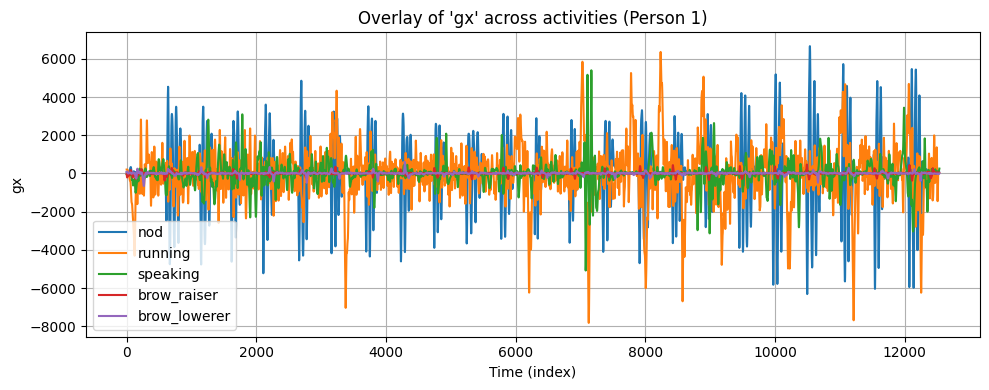

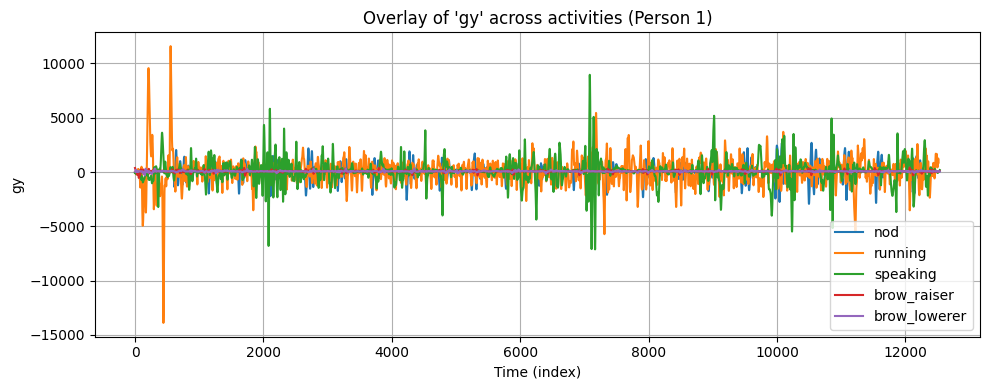

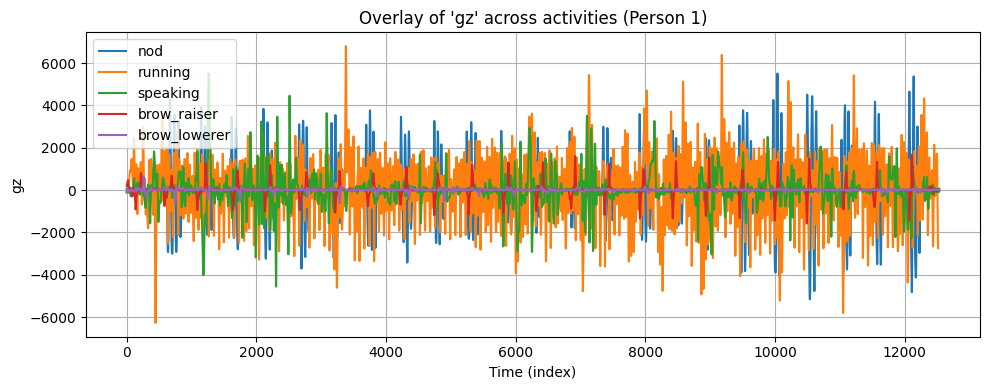

In [8]:
# File paths for few actions of the first person
file_paths = {
    'nod': "/kaggle/input/earbuds/EARBUDS/1-nod-imu-left.csv",
    'running': "/kaggle/input/earbuds/EARBUDS/1-running-imu-left.csv",
    'speaking': "/kaggle/input/earbuds/EARBUDS/1-speaking-imu-left.csv",
    'brow_raiser': "/kaggle/input/earbuds/EARBUDS/1-brow-raiser-imu-left.csv",
    'brow_lowerer': "/kaggle/input/earbuds/EARBUDS/1-brow-lowerer-imu-left.csv"
}

# Choosing which signal to overlay (e.g., 'ax', 'gy', etc.)
signals_to_plot = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']

# Plotting each signal separately
for signal in signals_to_plot:
    plt.figure(figsize=(10, 4))
    for activity, path in file_paths.items():
        df = pd.read_csv(path)
        filtered = butterworth_filter(df[signal].values)
        plt.plot(filtered, label=activity)
    
    plt.title(f"Overlay of '{signal}' across activities (Person 1)")
    plt.xlabel("Time (index)")
    plt.ylabel(signal)
    plt.legend()
    plt.tight_layout()
    plt.grid(True)
    plt.show()

## **Mean/STD for Understanding Fluctuations**

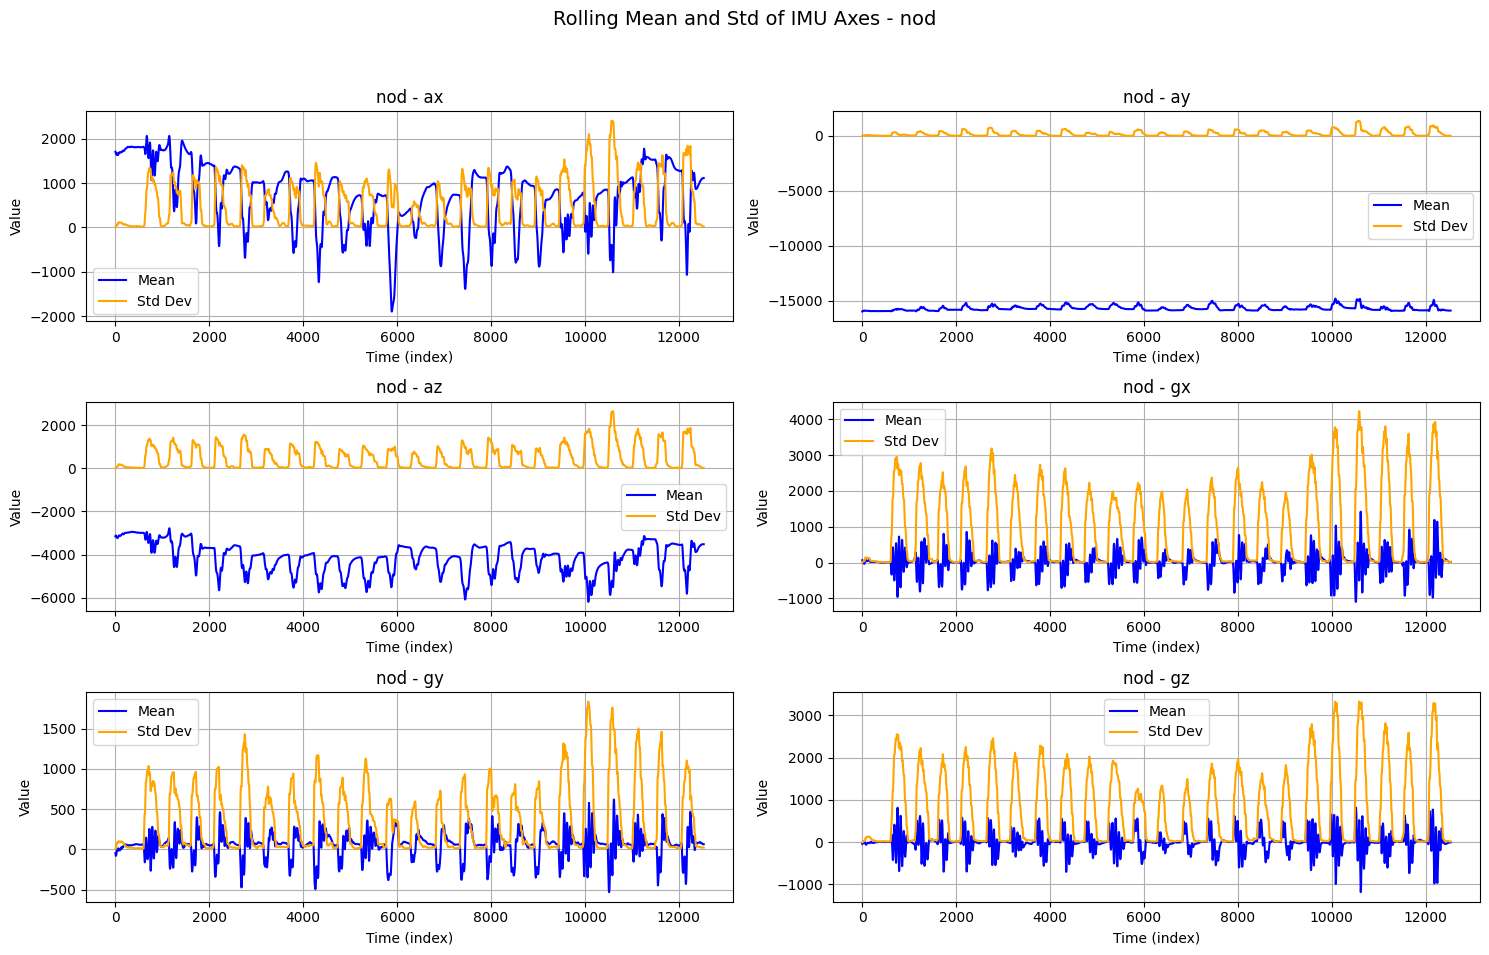

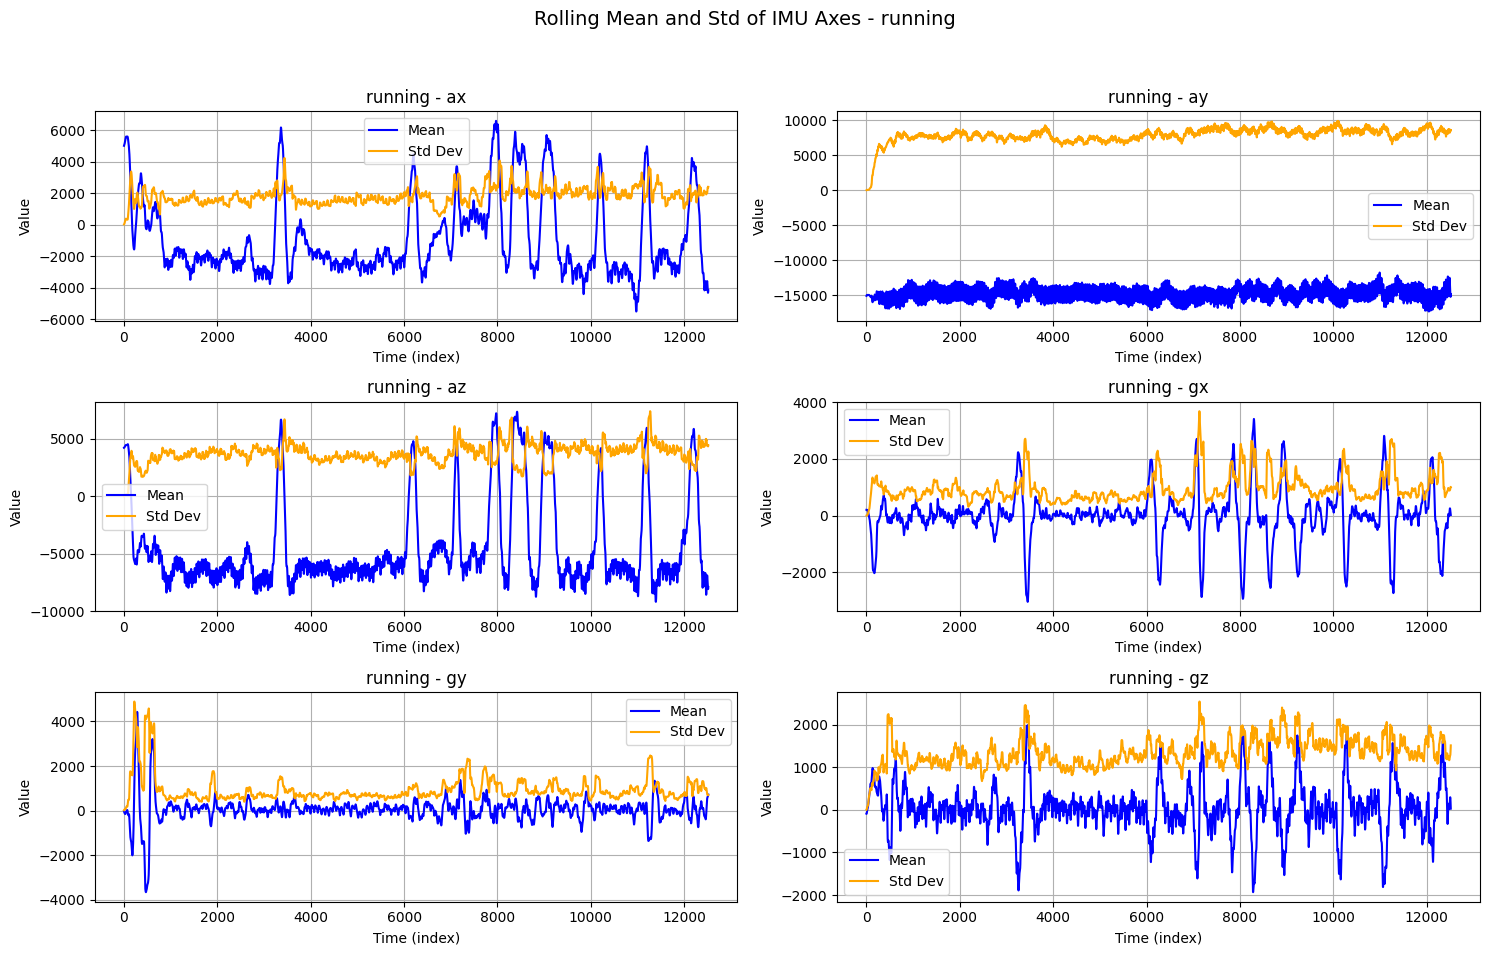

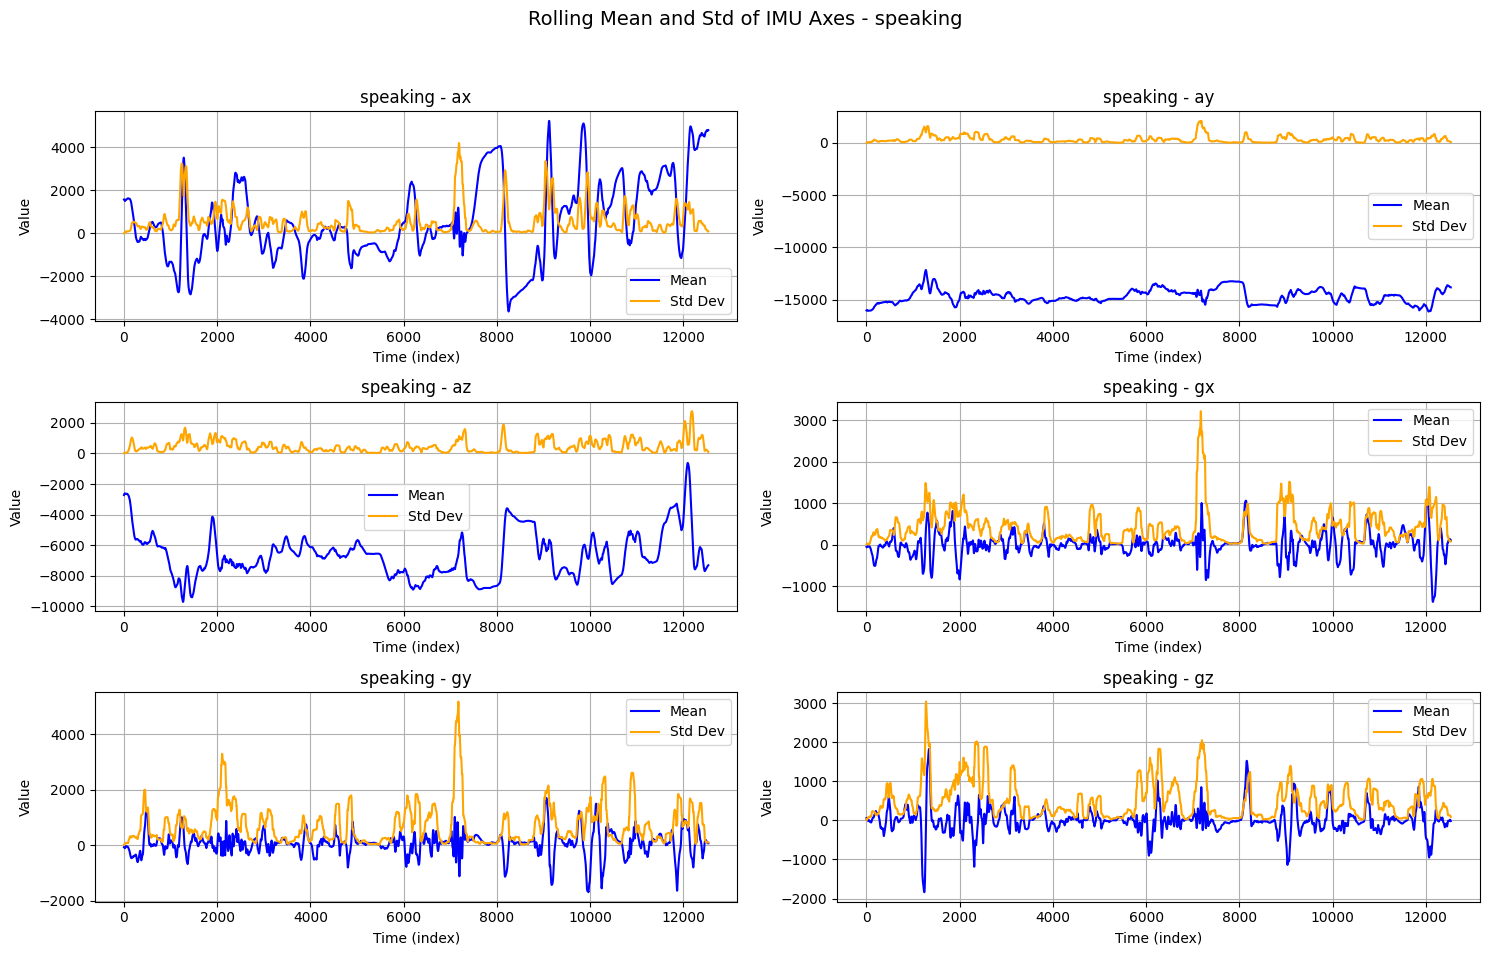

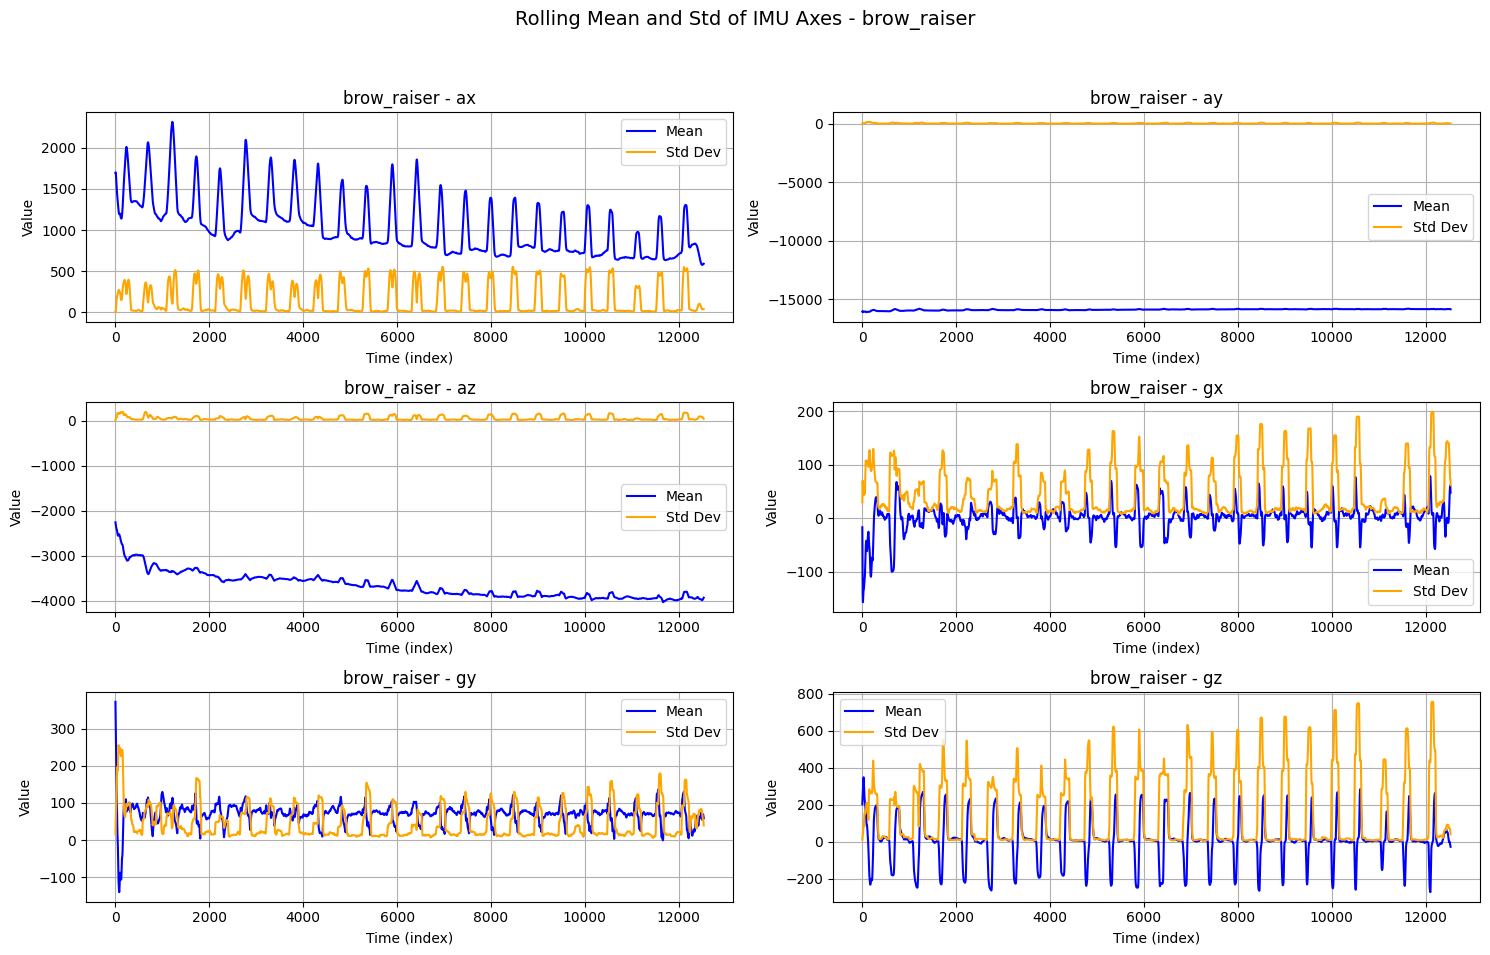

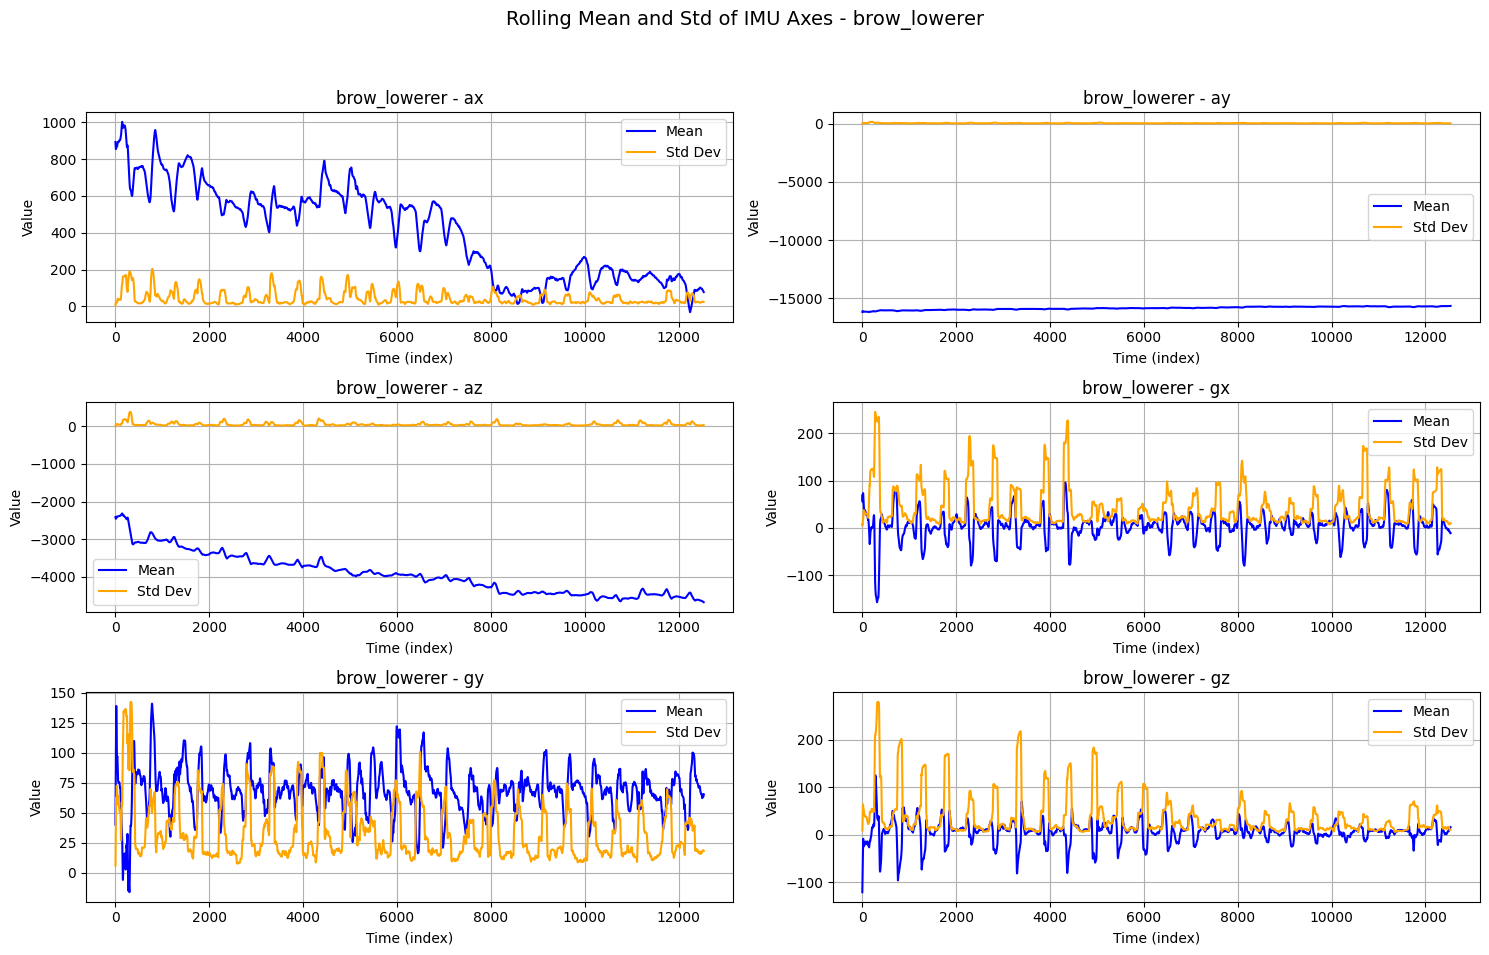

In [9]:
# Rolling stats
def compute_rolling_stats(signal, window=100):
    rolling_mean = pd.Series(signal).rolling(window=window, min_periods=1).mean()
    rolling_std = pd.Series(signal).rolling(window=window, min_periods=1).std()
    return rolling_mean, rolling_std

# Signals
sensor_axes = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']

# For each activity, plotting mean and std
for activity, path in file_paths.items():
    df = pd.read_csv(path)
    plt.figure(figsize=(15, 10))
    for i, axis in enumerate(sensor_axes, 1):
        signal = butterworth_filter(df[axis].values)
        mean, std = compute_rolling_stats(signal)
        
        plt.subplot(3, 2, i)
        plt.plot(mean, label='Mean', color='blue')
        plt.plot(std, label='Std Dev', color='orange')
        plt.title(f"{activity} - {axis}")
        plt.xlabel("Time (index)")
        plt.ylabel("Value")
        plt.legend()
        plt.grid(True)

    plt.suptitle(f"Rolling Mean and Std of IMU Axes - {activity}", fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

## **Kernel Density Estimate (KDE) Graph**

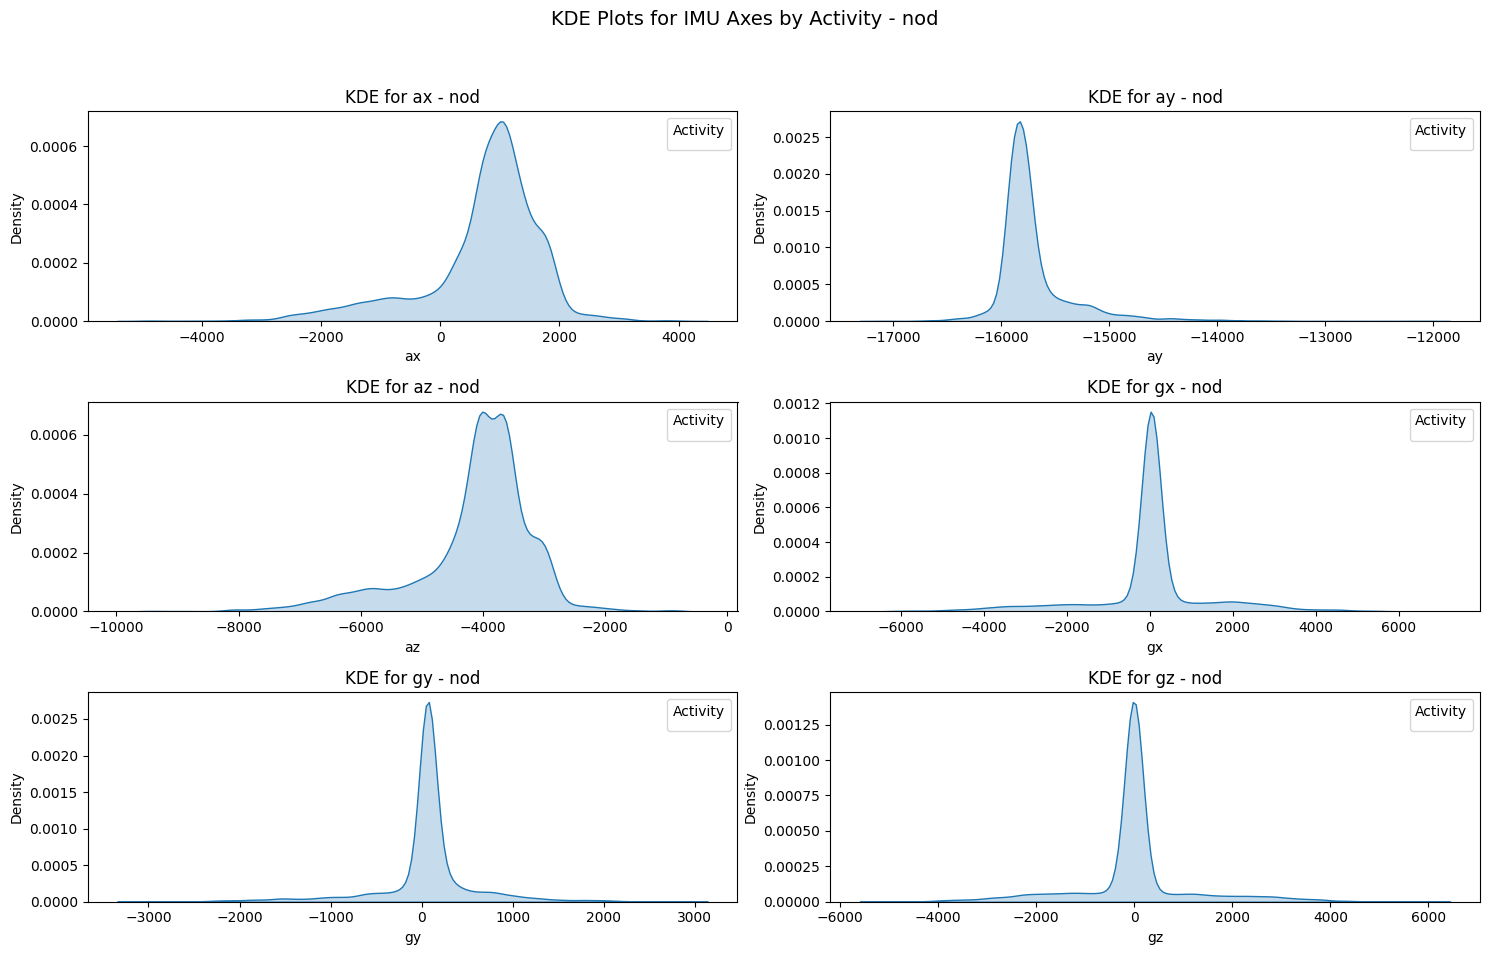

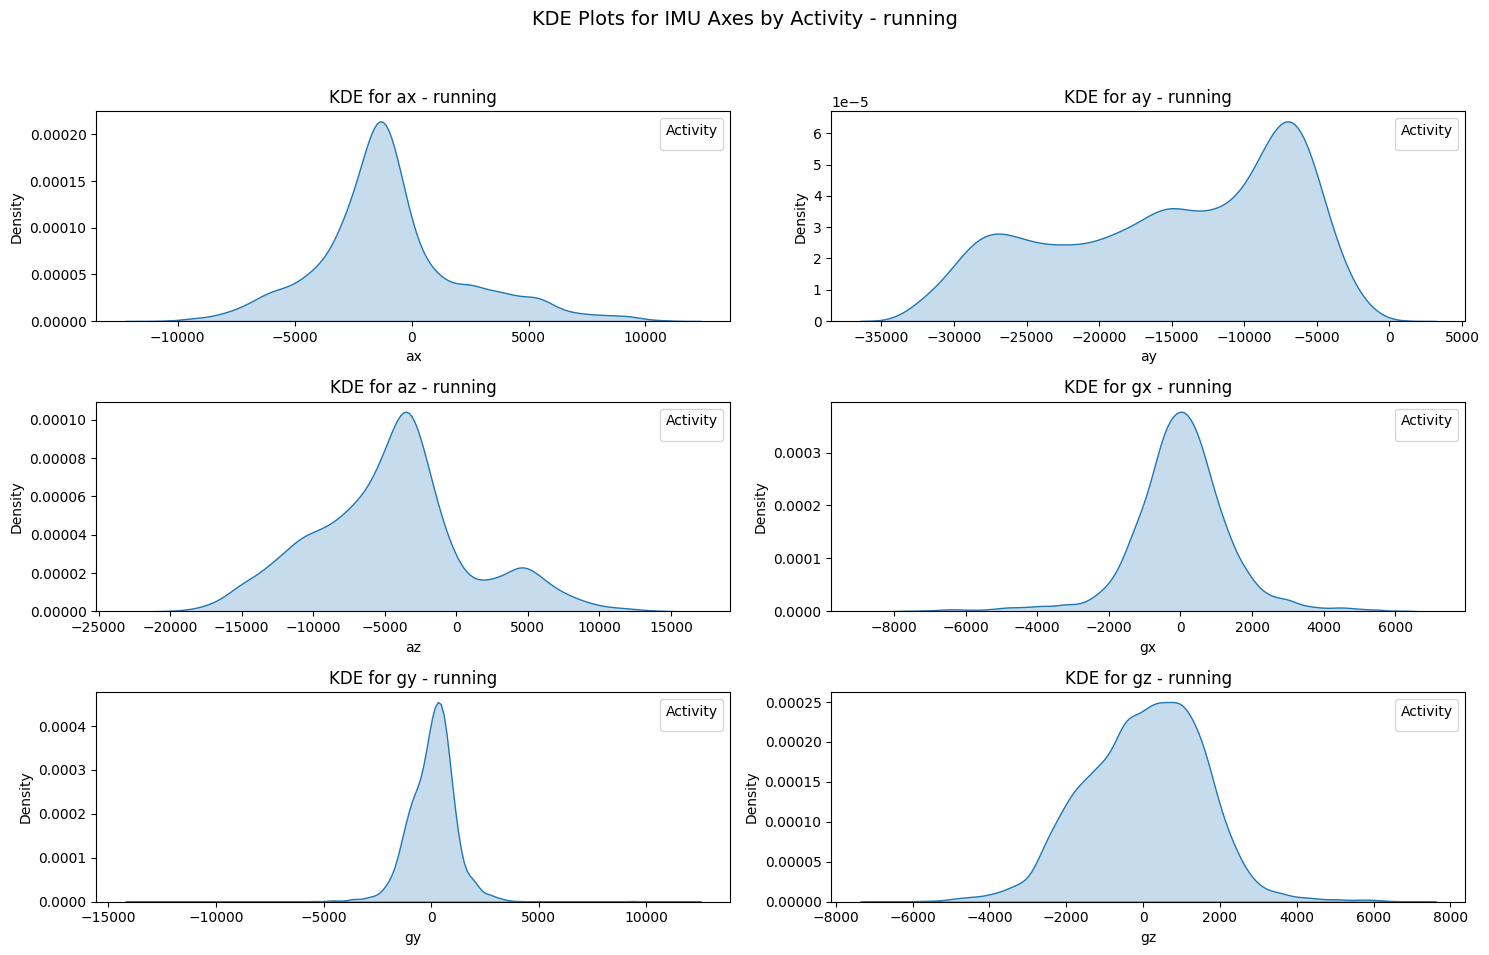

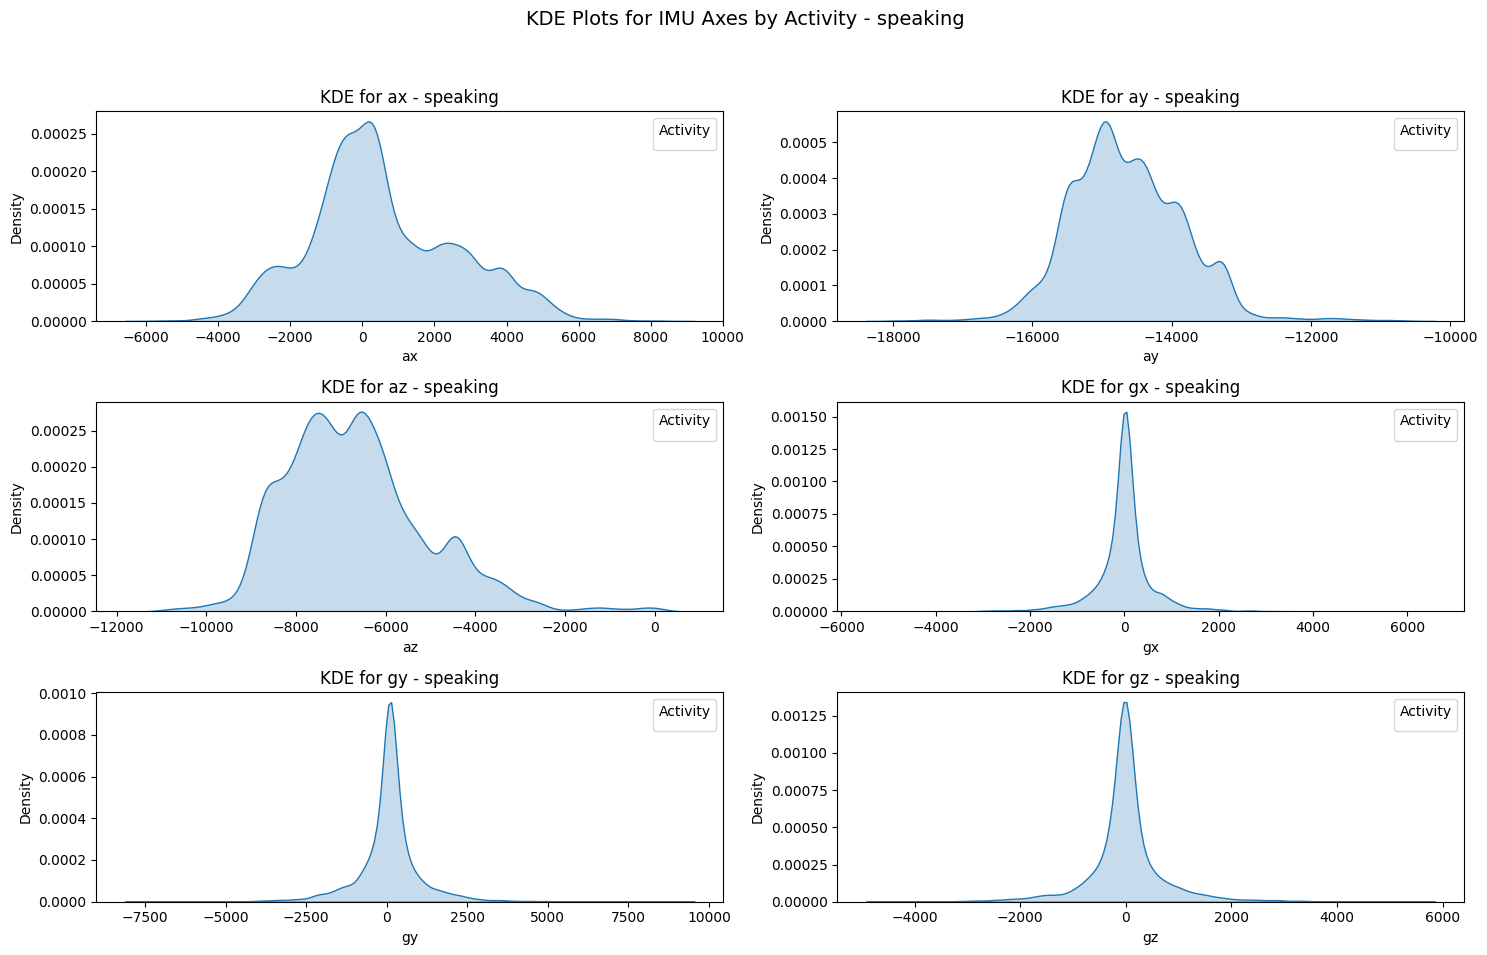

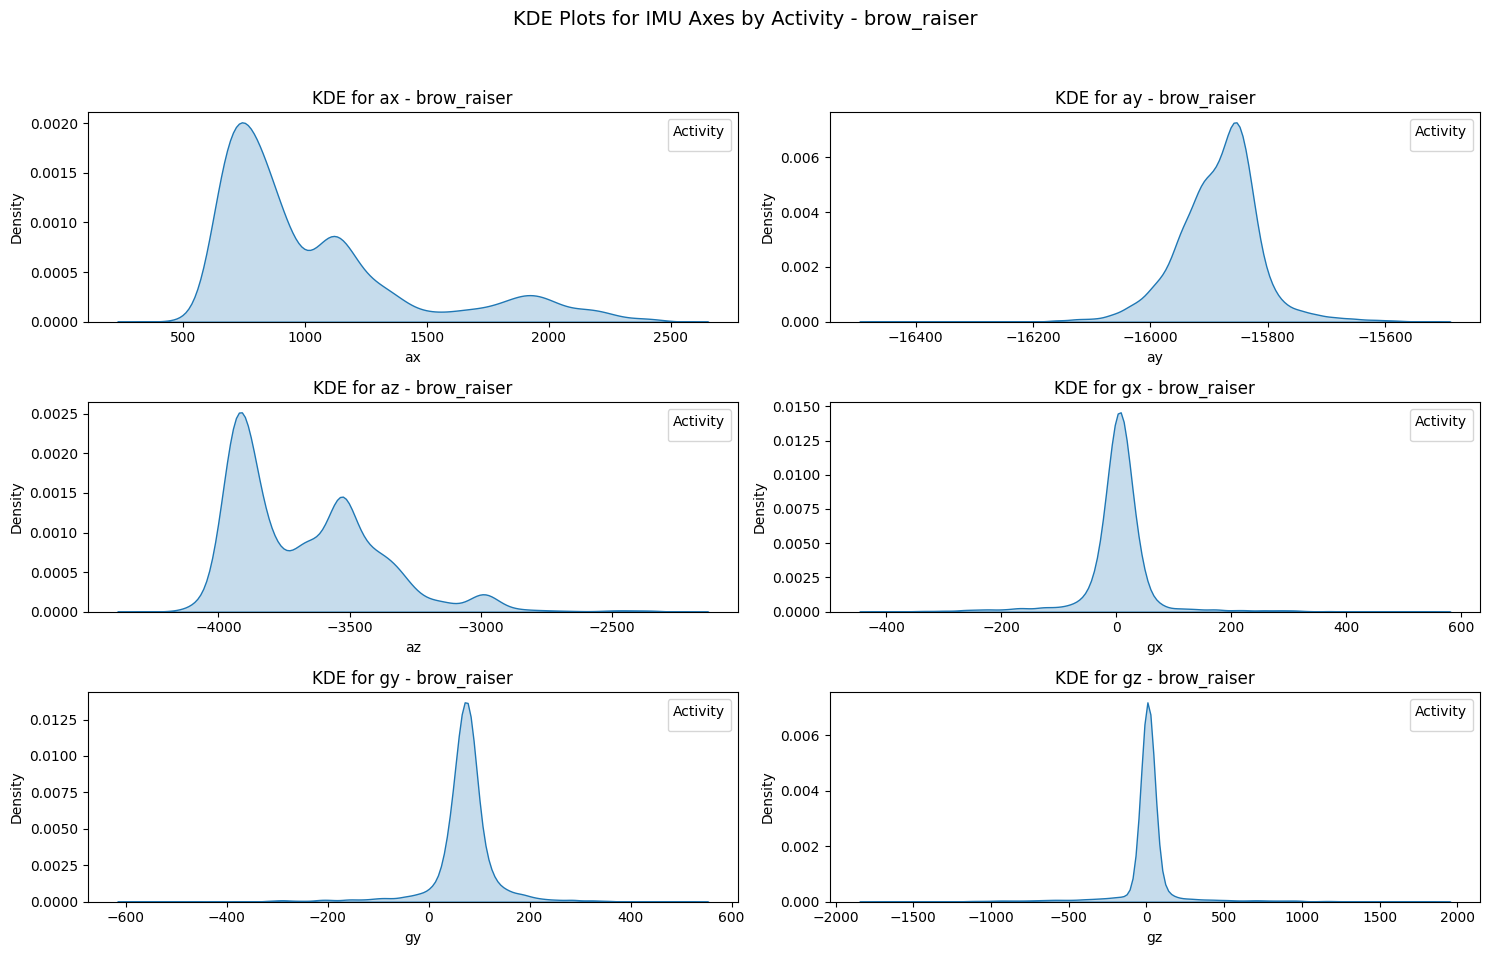

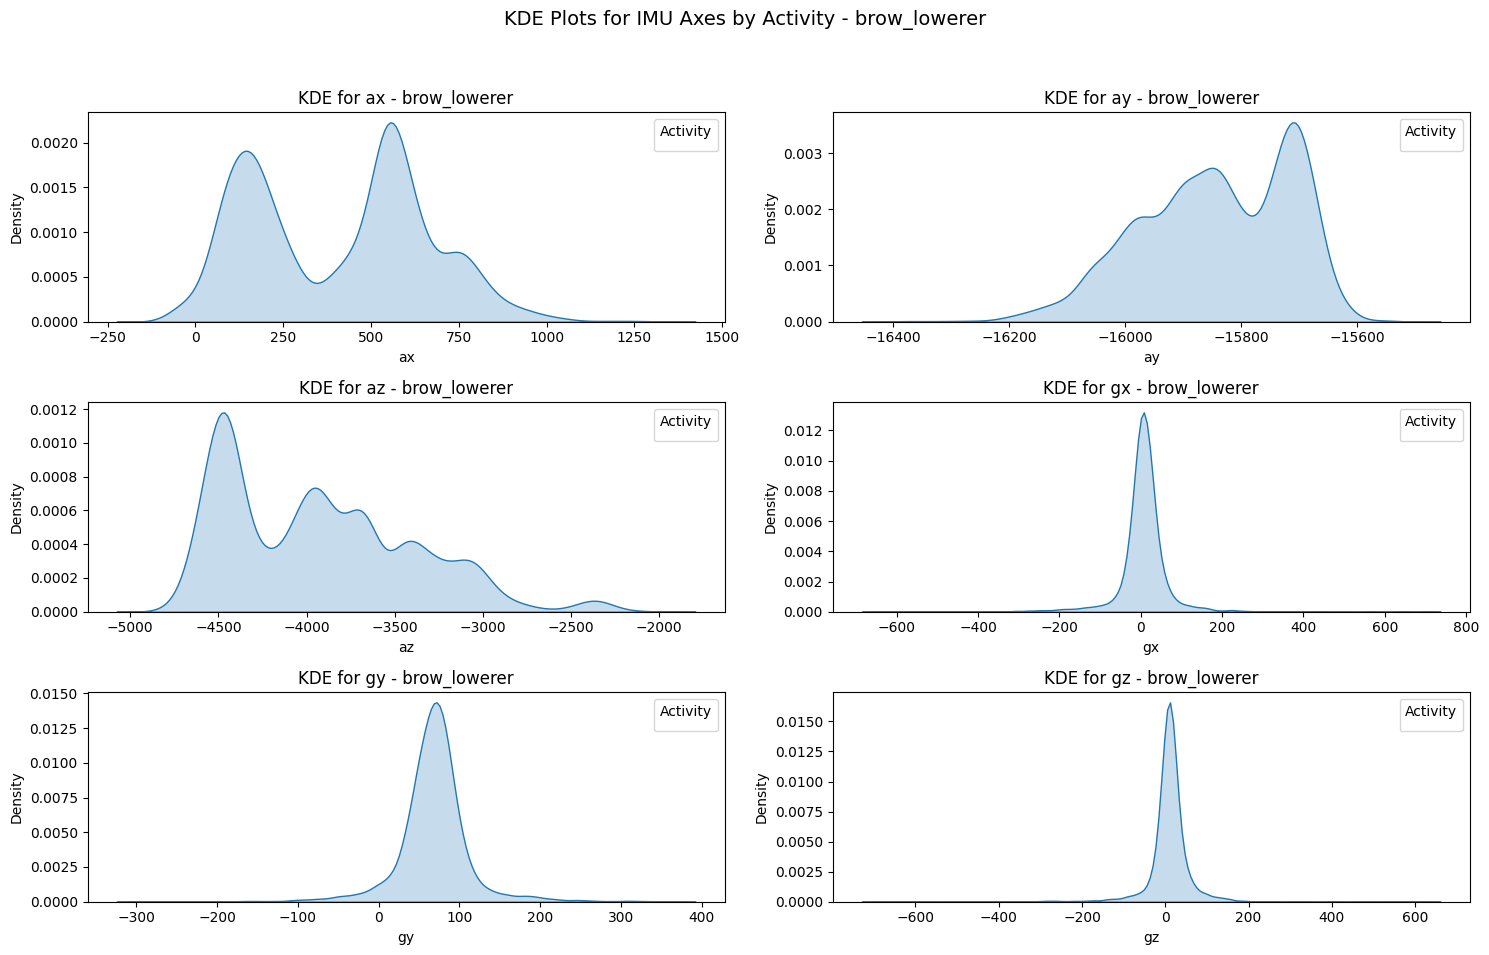

In [27]:
# Plotting KDE for each feature and activity class
for activity, path in file_paths.items():
    df = pd.read_csv(path)
    df['label'] = activity
    
    # Plotting KDE for each sensor axis
    plt.figure(figsize=(15, 10))
    
    for i, axis in enumerate(sensor_axes, 1):
        plt.subplot(3, 2, i)
        sns.kdeplot(data=df, x=axis, hue='label', common_norm=False, fill=True)
        plt.title(f"KDE for {axis} - {activity}")
        plt.xlabel(axis)
        plt.ylabel("Density")
        plt.legend(title="Activity")

    plt.suptitle(f"KDE Plots for IMU Axes by Activity - {activity}", fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

## **Each Feature-wise KDE**

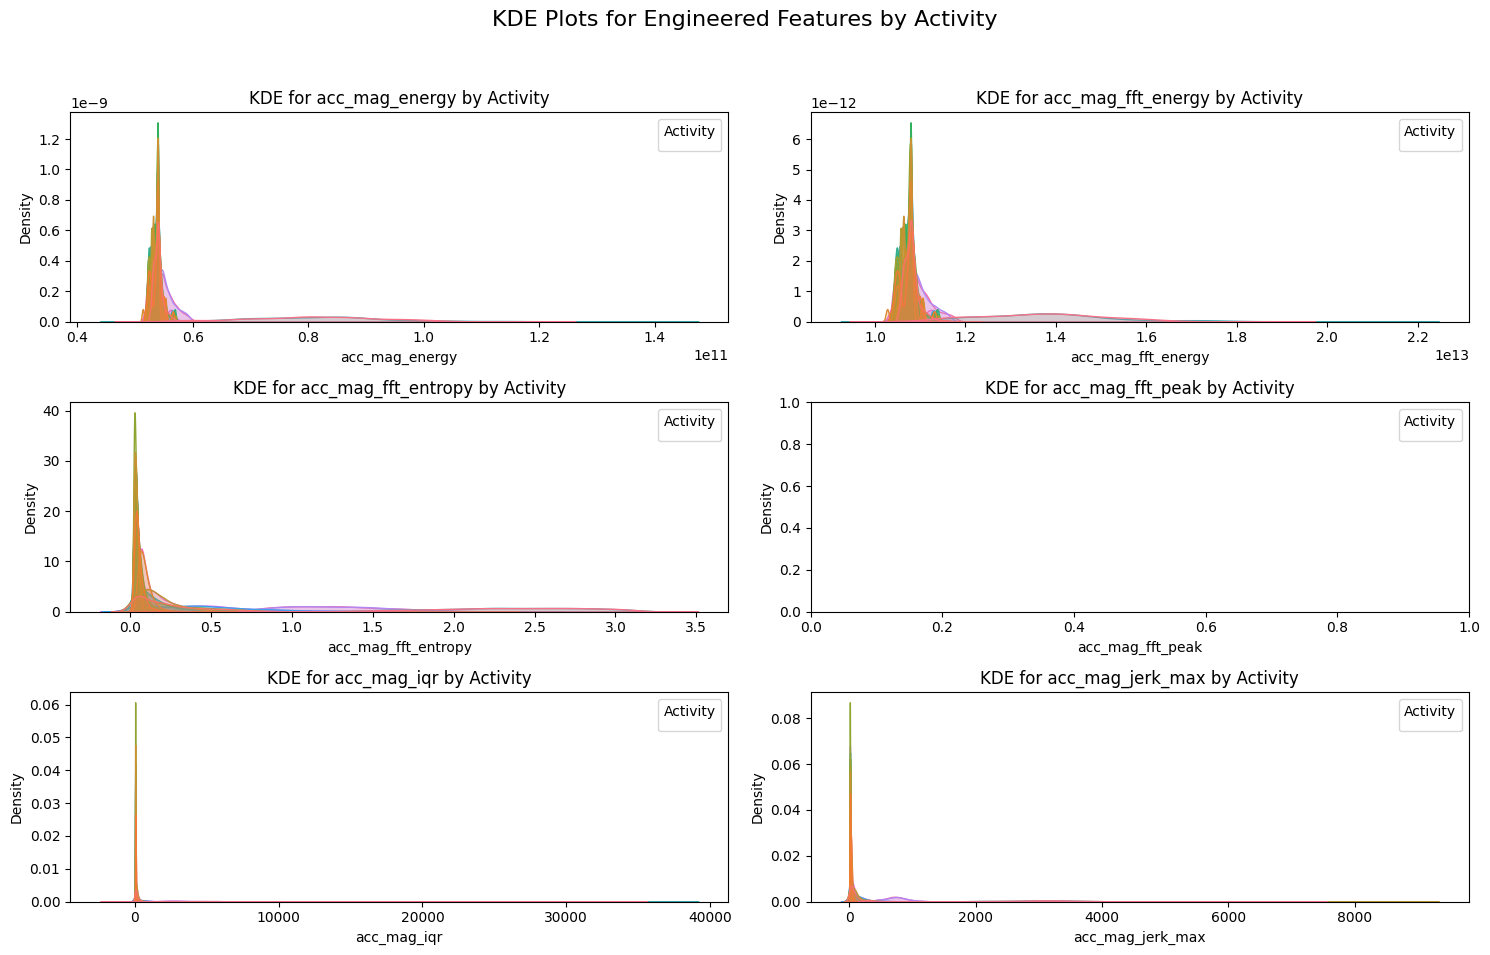

In [10]:
# List of engineered features
engineered_features = df_features_windowed.columns.difference(['label', 'person_id', 'filename'])

# Plotting KDE for each engineered feature and activity class
plt.figure(figsize=(15, 10))
for i, feature in enumerate(engineered_features[:6], 1):  # Plotting first 6 features
    plt.subplot(3, 2, i)
    sns.kdeplot(data=df_features_windowed, x=feature, hue='label', common_norm=False, fill=True)
    plt.title(f"KDE for {feature} by Activity")
    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.legend(title="Activity")

plt.suptitle("KDE Plots for Engineered Features by Activity", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## **Correlation**

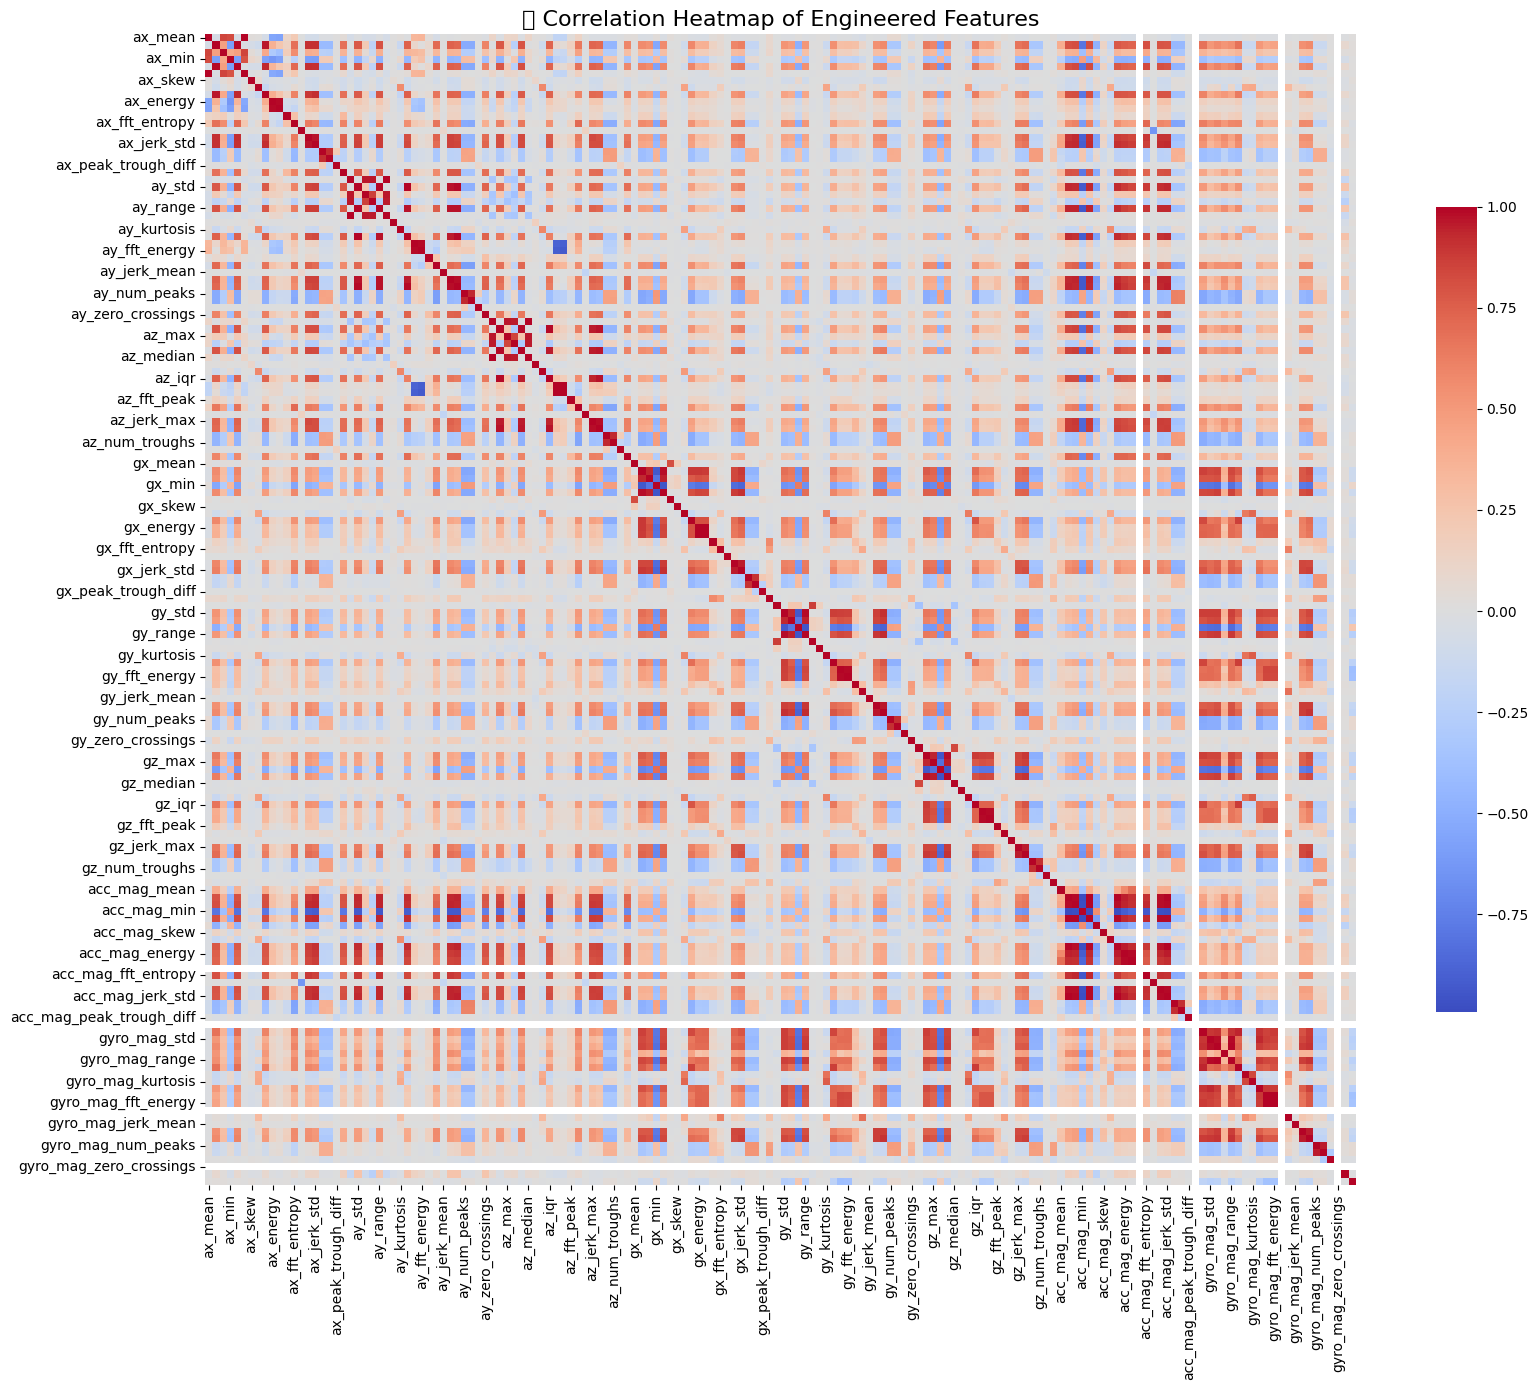

In [11]:
# Only keeping the numeric feature columns
feature_cols = [col for col in df_features_windowed.columns 
                if col not in ['label', 'encoded_label', 'filename', 'person_id'] 
                and df_features_windowed[col].dtype != 'object']

# Computing correlation matrix
corr_matrix = df_features_windowed[feature_cols].corr()

# Plotting heatmap
plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False, fmt=".2f", 
            square=True, cbar_kws={'shrink': 0.7})
plt.title("Correlation Heatmap of Engineered Features", fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [12]:
# Finding highly correlated feature pairs (above 0.9 but not self-correlation)
high_corr = corr_matrix.abs().unstack().sort_values(ascending=False)
high_corr = high_corr[high_corr < 1.0]
high_corr = high_corr[high_corr > 0.9]

print("Highly correlated feature pairs:\n", high_corr)

Highly correlated feature pairs:
 ay_median         ay_mean              0.999457
ay_mean           ay_median            0.999457
az_median         az_mean              0.999268
az_mean           az_median            0.999268
gyro_mag_max      gyro_mag_range       0.998789
                                         ...   
gyro_mag_range    gyro_mag_jerk_std    0.901746
acc_mag_jerk_std  ax_jerk_max          0.901354
ax_jerk_max       acc_mag_jerk_std     0.901354
gx_num_troughs    gx_num_peaks         0.900376
gx_num_peaks      gx_num_troughs       0.900376
Length: 354, dtype: float64


## **Distribution of Actions**

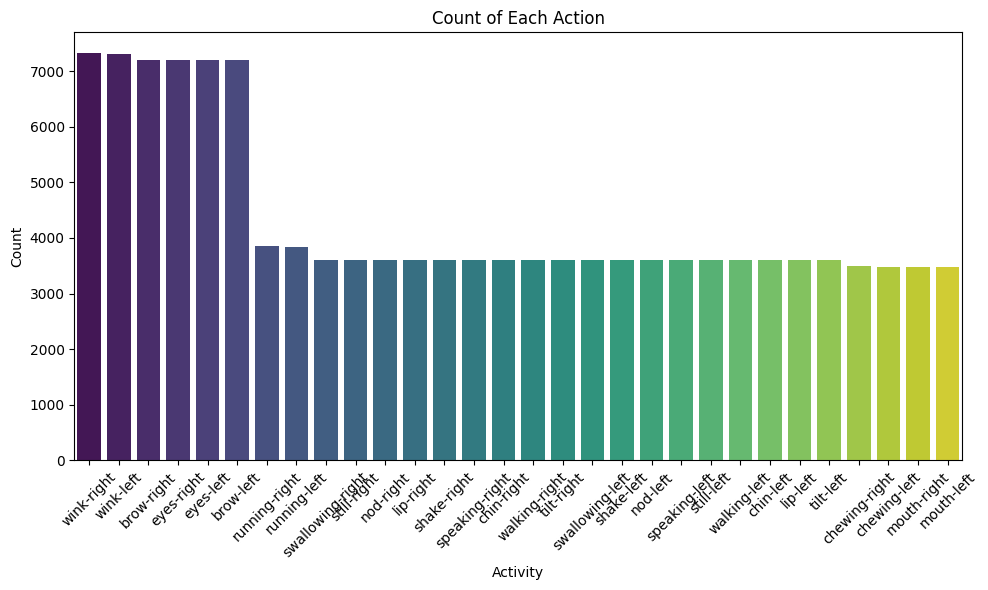

In [17]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_features_windowed, x='label', order=df_features_windowed['label'].value_counts().index, palette='viridis')
plt.title("Count of Each Action")
plt.xlabel("Activity")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

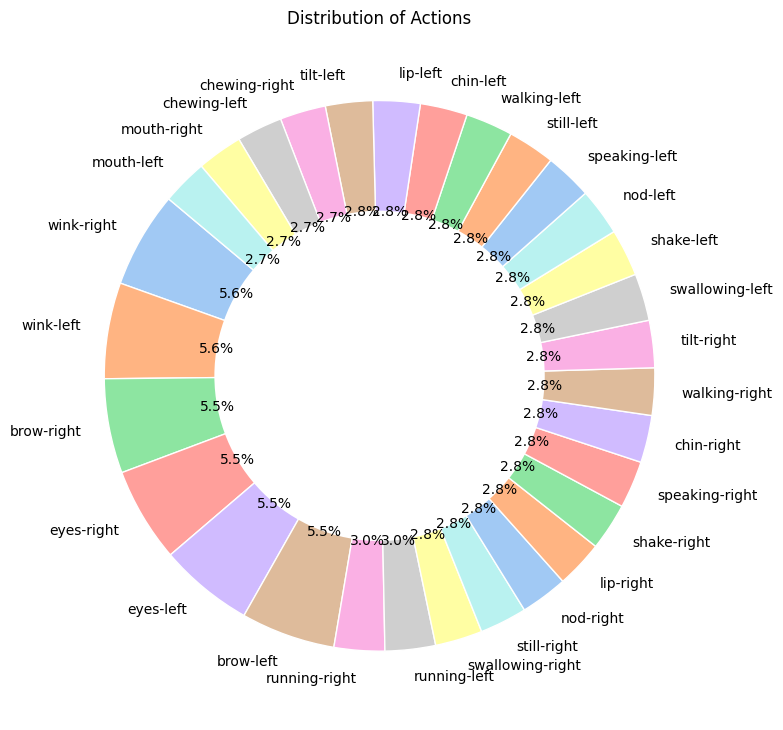

In [16]:
# Count of each label
label_counts = df_features_windowed['label'].value_counts()

# Pie chart with a donut hole
plt.figure(figsize=(8, 8))
colors = sns.color_palette('pastel')[0:len(label_counts)]

plt.pie(label_counts, labels=label_counts.index, colors=colors, autopct='%1.1f%%', startangle=140, wedgeprops={'linewidth': 1, 'edgecolor': 'white'})
centre_circle = plt.Circle((0,0),0.60,fc='white')
plt.gca().add_artist(centre_circle)

plt.title("Distribution of Actions")
plt.tight_layout()
plt.show()

# **LightGBM**

In [8]:
# Label encoding
le = LabelEncoder()
df_features_windowed['encoded_label'] = le.fit_transform(df_features_windowed['label'])

# Saving person_id before splitting
person_ids = df_features_windowed['person_id'].values

# Selecting features
feature_cols = [col for col in df_features_windowed.columns if col not in ['label', 'encoded_label', 'filename', 'person_id']]
X = df_features_windowed[feature_cols]
y = df_features_windowed['encoded_label']

# Splitting
X_train, X_test, y_train, y_test, person_id_train, person_id_test = train_test_split(
    X, y, person_ids, stratify=y, test_size=0.2, random_state=42
)

# Model
lgb_clf = LGBMClassifier(
    objective='multiclass',
    num_class=len(le.classes_),
    learning_rate=0.05,
    num_leaves=64,
    max_depth=-1,
    random_state=42,
    n_estimators=1000
)

# Training with callbacks
lgb_clf.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='multi_logloss',
    callbacks=[
        early_stopping(stopping_rounds=100),
        log_evaluation(period=100)
    ]
)

# Predicting and evaluating
y_pred = lgb_clf.predict(X_test)
df_test = pd.DataFrame({
    'y_true': y_test,
    'y_pred': y_pred,
    'person_id': person_id_test
})
# Collecting scores per person
person_scores = []
for person_id in sorted(df_test['person_id'].unique()):
    df_p = df_test[df_test['person_id'] == person_id]
    y_true_p = df_p['y_true']
    y_pred_p = df_p['y_pred']
    
    person_scores.append({
        'person_id': person_id,
        'Accuracy': accuracy_score(y_true_p, y_pred_p),
        'Precision': precision_score(y_true_p, y_pred_p, average='weighted', zero_division=0),
        'Recall': recall_score(y_true_p, y_pred_p, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_true_p, y_pred_p, average='weighted', zero_division=0)
    })

df_person_scores = pd.DataFrame(person_scores)
acc = accuracy_score(y_test, y_pred)
print()
print(f"LightGBM Accuracy: {acc * 100:.2f}%")
print()
print(classification_report(y_test, y_pred, target_names=le.classes_))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.120974 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 31548
[LightGBM] [Info] Number of data points in the train set: 103887, number of used features: 158
[LightGBM] [Info] Start training from score -2.893409
[LightGBM] [Info] Start training from score -2.891499
[LightGBM] [Info] Start training from score -3.618338
[LightGBM] [Info] Start training from score -3.615830
[LightGBM] [Info] Start training from score -3.586556
[LightGBM] [Info] Start training from score -3.584819
[LightGBM] [Info] Start training from score -2.893409
[LightGBM] [Info] Start training from score -2.891499
[LightGBM] [Info] Start training from score -3.586556
[LightGBM] [Info] Start training from score -3.584819
[LightGBM] [Info] Start training from score -3.621573
[LightGBM] [Info] Start training from score -3.619774
[LightGBM] [Info] Start training from score -3.586556
[Light

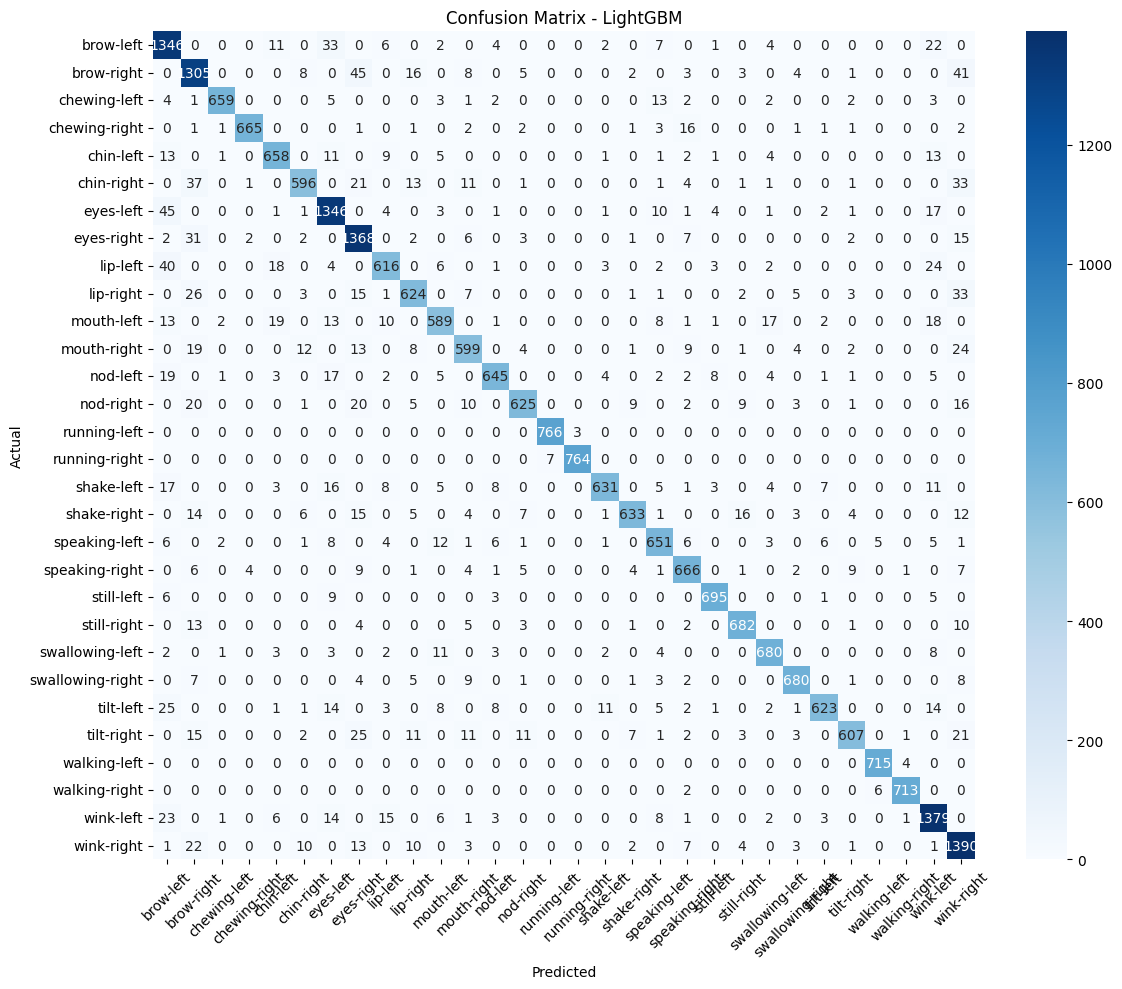

In [9]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix - LightGBM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

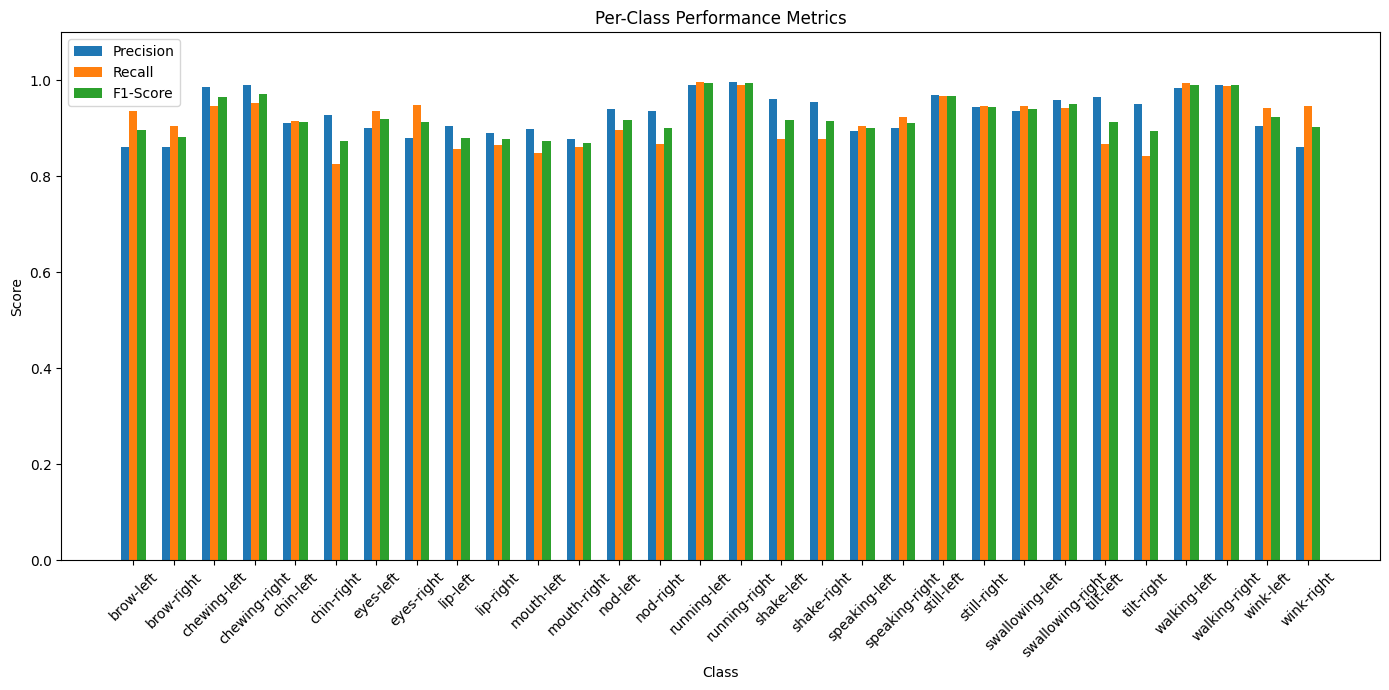

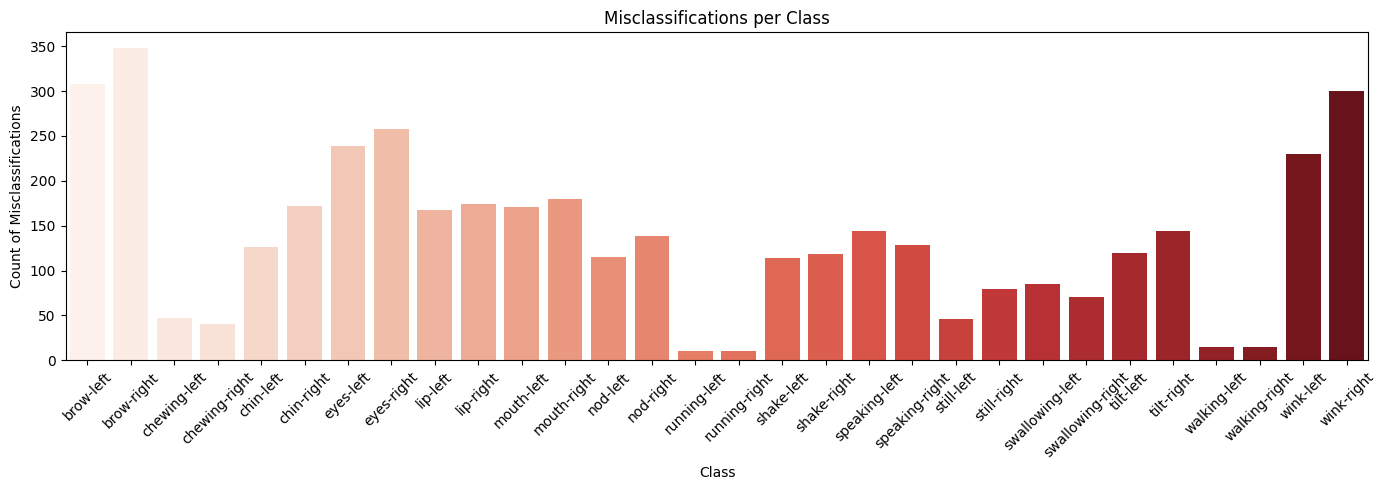

In [10]:
# Initialising lists to store the metrics
classes = le.classes_
precisions, recalls, f1_scores, misclassifications = [], [], [], []

for idx, label in enumerate(classes):
    true_positives = cm[idx, idx]
    false_negatives = cm[idx].sum() - true_positives
    false_positives = cm[:, idx].sum() - true_positives
    true_negatives = cm.sum() - (true_positives + false_negatives + false_positives)

    precision = true_positives / (true_positives + false_positives + 1e-10)
    recall = true_positives / (true_positives + false_negatives + 1e-10)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-10)
    misclassified = false_negatives + false_positives

    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)
    misclassifications.append(misclassified)

# Plotting grouped bar chart
x = np.arange(len(classes))
width = 0.2

plt.figure(figsize=(14, 7))
plt.bar(x - width, precisions, width=width, label='Precision')
plt.bar(x, recalls, width=width, label='Recall')
plt.bar(x + width, f1_scores, width=width, label='F1-Score')
plt.xticks(x, classes, rotation=45)
plt.title("Per-Class Performance Metrics")
plt.xlabel("Class")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.show()

# Plotting misclassifications separately
plt.figure(figsize=(14, 5))
sns.barplot(x=classes, y=misclassifications, palette='Reds')
plt.title("Misclassifications per Class")
plt.xlabel("Class")
plt.ylabel("Count of Misclassifications")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
best_person = df_person_scores.loc[df_person_scores['Accuracy'].idxmax()]
print(f"Highest Accuracy for LightGBM: {best_person['Accuracy']:.2%} by Person {int(best_person['person_id'])}")

Highest Accuracy for LightGBM: 98.23% by Person 27


In [13]:
best_person = df_person_scores.loc[df_person_scores['F1-Score'].idxmax()]
print(f"Highest F1-score for LightGBM: {best_person['F1-Score']:.2%} by Person {int(best_person['person_id'])}")

Highest F1-score for LightGBM: 98.24% by Person 27


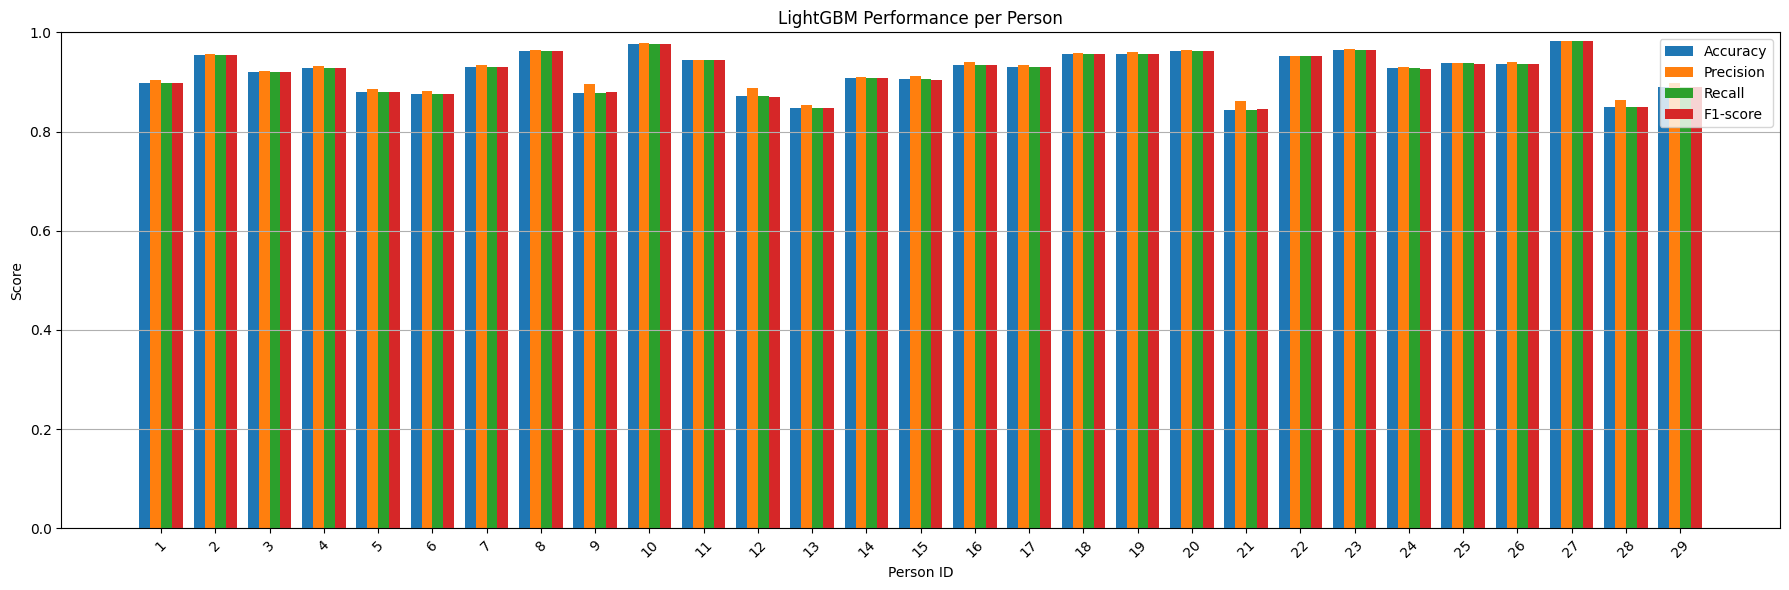

In [14]:
# Metrics and colour map
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

x = np.arange(len(df_person_scores))
width = 0.2

fig, ax = plt.subplots(figsize=(18, 6))

for i, metric in enumerate(metrics):
    ax.bar(
        x + i * width,
        df_person_scores[metric],
        width,
        label=metric.capitalize(),
        color=colors[i]
    )

ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(df_person_scores['person_id'].astype(str), rotation=45)
ax.set_xlabel('Person ID')
ax.set_ylabel('Score')
ax.set_title('LightGBM Performance per Person')
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(axis='y')

plt.tight_layout()
plt.show()

# **XGBoost**

In [15]:
# XGBoost model
xgb_model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=len(le.classes_),
    max_depth=10,
    learning_rate=0.1,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

# Per-person evaluation
person_scores = []
unique_test_pids = np.unique(person_id_test)

for pid in unique_test_pids:
    mask = (person_id_test == pid)
    X_person = X_test[mask]
    y_person = y_test[mask]

    if len(y_person) == 0:
        continue

    y_pred = xgb_model.predict(X_person)

    acc = accuracy_score(y_person, y_pred)
    prec = precision_score(y_person, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_person, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_person, y_pred, average='macro', zero_division=0)

    person_scores.append({
        'person_id': pid,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

df_person_scores = pd.DataFrame(person_scores)

# Evaluation
y_pred = xgb_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"XGBoost Accuracy: {acc * 100:.2f}%")
print()
print(classification_report(y_test, y_pred, target_names=le.classes_))

XGBoost Accuracy: 91.30%

                  precision    recall  f1-score   support

       brow-left       0.87      0.93      0.90      1438
      brow-right       0.87      0.89      0.88      1441
    chewing-left       0.97      0.94      0.95       697
   chewing-right       0.97      0.95      0.96       698
       chin-left       0.91      0.92      0.91       719
      chin-right       0.91      0.83      0.86       721
       eyes-left       0.90      0.93      0.91      1438
      eyes-right       0.88      0.95      0.91      1441
        lip-left       0.90      0.84      0.87       719
       lip-right       0.88      0.85      0.86       721
      mouth-left       0.89      0.84      0.86       694
     mouth-right       0.86      0.81      0.84       696
        nod-left       0.94      0.88      0.91       719
       nod-right       0.92      0.86      0.89       721
    running-left       0.99      1.00      0.99       769
   running-right       0.99      0.99      0.

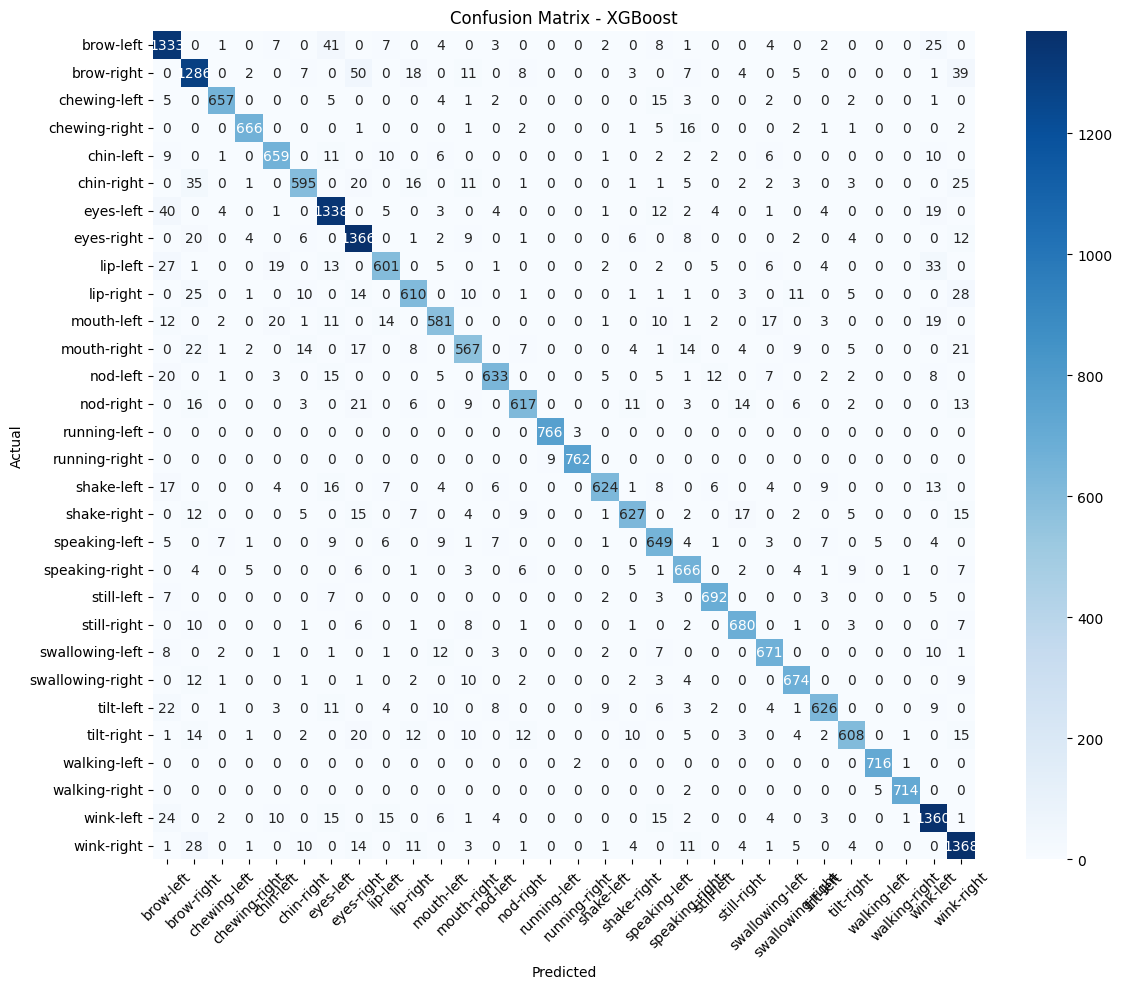

In [24]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

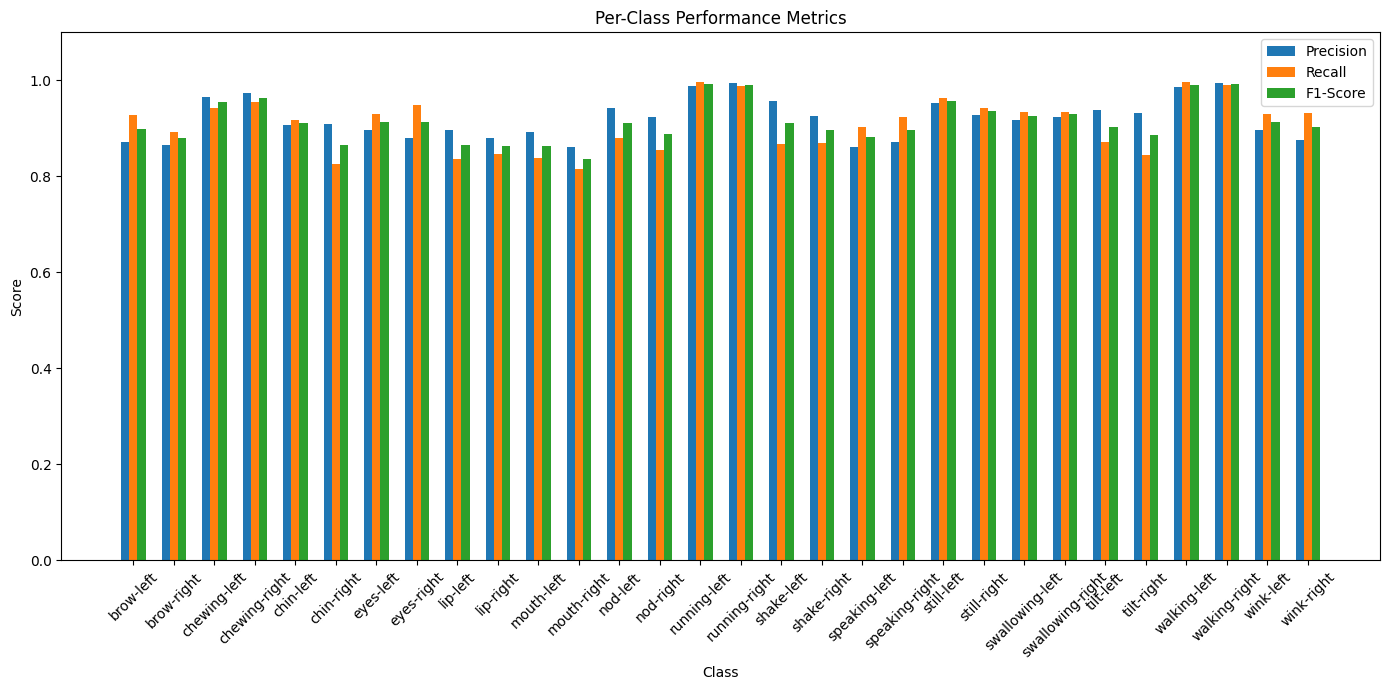

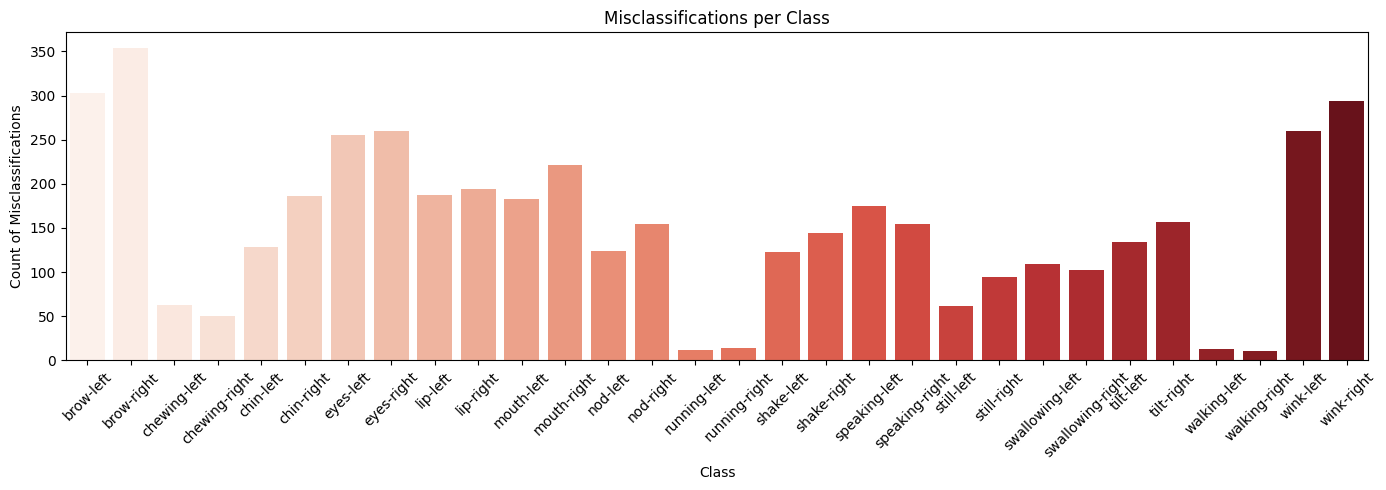

In [17]:
# Initialising lists to store the metrics
classes = le.classes_
precisions, recalls, f1_scores, misclassifications = [], [], [], []

for idx, label in enumerate(classes):
    true_positives = cm[idx, idx]
    false_negatives = cm[idx].sum() - true_positives
    false_positives = cm[:, idx].sum() - true_positives
    true_negatives = cm.sum() - (true_positives + false_negatives + false_positives)

    precision = true_positives / (true_positives + false_positives + 1e-10)
    recall = true_positives / (true_positives + false_negatives + 1e-10)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-10)
    misclassified = false_negatives + false_positives

    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)
    misclassifications.append(misclassified)

# Plotting grouped bar chart
x = np.arange(len(classes))
width = 0.2

plt.figure(figsize=(14, 7))
plt.bar(x - width, precisions, width=width, label='Precision')
plt.bar(x, recalls, width=width, label='Recall')
plt.bar(x + width, f1_scores, width=width, label='F1-Score')
plt.xticks(x, classes, rotation=45)
plt.title("Per-Class Performance Metrics")
plt.xlabel("Class")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.show()

# Plotting misclassifications separately
plt.figure(figsize=(14, 5))
sns.barplot(x=classes, y=misclassifications, palette='Reds')
plt.title("Misclassifications per Class")
plt.xlabel("Class")
plt.ylabel("Count of Misclassifications")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
# Printing best performer
best_person = df_person_scores.loc[df_person_scores['Accuracy'].idxmax()]
print(f"Highest Accuracy for XGBoost: {best_person['Accuracy']:.2%} by Person {int(best_person['person_id'])}")

Highest Accuracy for XGBoost: 97.90% by Person 10


In [19]:
# Person with highest F1 score
best_person = df_person_scores.loc[df_person_scores['F1-Score'].idxmax()]
print(f"Highest F1-score for XGBoost: {best_person['F1-Score']:.2%} by Person {int(best_person['person_id'])}")

Highest F1-score for XGBoost: 98.01% by Person 27


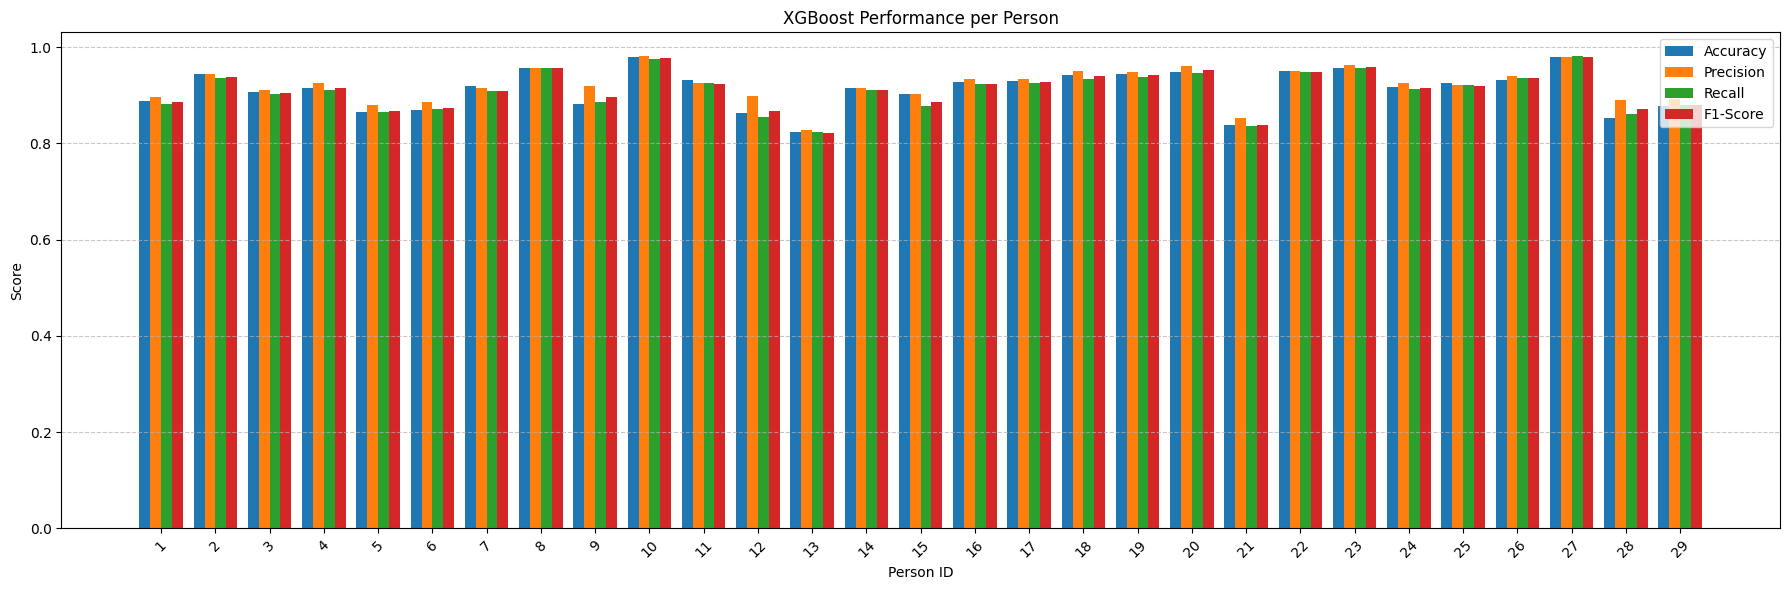

In [20]:
plt.figure(figsize=(18, 6))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(df_person_scores))
width = 0.2

for i, metric in enumerate(metrics):
    plt.bar(x + i * width, df_person_scores[metric], width, label=metric)

plt.xticks(x + 1.5 * width, df_person_scores['person_id'].astype(str), rotation=45)
plt.xlabel("Person ID")
plt.ylabel("Score")
plt.title("XGBoost Performance per Person")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# **ExtraTrees Classifier**

In [22]:
# Training ExtraTrees
et_model = ExtraTreesClassifier(n_estimators=400, random_state=42)
et_model.fit(X_train, y_train)

# Per-person evaluation
person_scores_et = []
unique_test_pids = np.unique(person_id_test)

for pid in unique_test_pids:
    mask = (person_id_test == pid)
    X_person = X_test[mask]
    y_person = y_test[mask]

    if len(y_person) == 0:
        continue

    y_pred_person = et_model.predict(X_person)

    acc = accuracy_score(y_person, y_pred_person)
    prec = precision_score(y_person, y_pred_person, average='macro', zero_division=0)
    rec = recall_score(y_person, y_pred_person, average='macro', zero_division=0)
    f1 = f1_score(y_person, y_pred_person, average='macro', zero_division=0)

    person_scores_et.append({
        'person_id': pid,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

df_person_scores_et = pd.DataFrame(person_scores_et)
y_pred_et = et_model.predict(X_test)
acc = accuracy_score(y_test, y_pred_et)
print(f"ExtraTrees Accuracy: {acc * 100:.2f}%")
print()
print(classification_report(y_test, y_pred_et, target_names=le.classes_))

ExtraTrees Accuracy: 91.49%

                  precision    recall  f1-score   support

       brow-left       0.86      0.93      0.89      1438
      brow-right       0.88      0.91      0.90      1441
    chewing-left       0.96      0.95      0.95       697
   chewing-right       0.96      0.95      0.96       698
       chin-left       0.93      0.89      0.91       719
      chin-right       0.93      0.86      0.89       721
       eyes-left       0.90      0.92      0.91      1438
      eyes-right       0.87      0.94      0.90      1441
        lip-left       0.93      0.84      0.88       719
       lip-right       0.91      0.87      0.89       721
      mouth-left       0.90      0.84      0.87       694
     mouth-right       0.89      0.83      0.86       696
        nod-left       0.93      0.88      0.90       719
       nod-right       0.96      0.83      0.89       721
    running-left       0.99      1.00      0.99       769
   running-right       1.00      0.99     

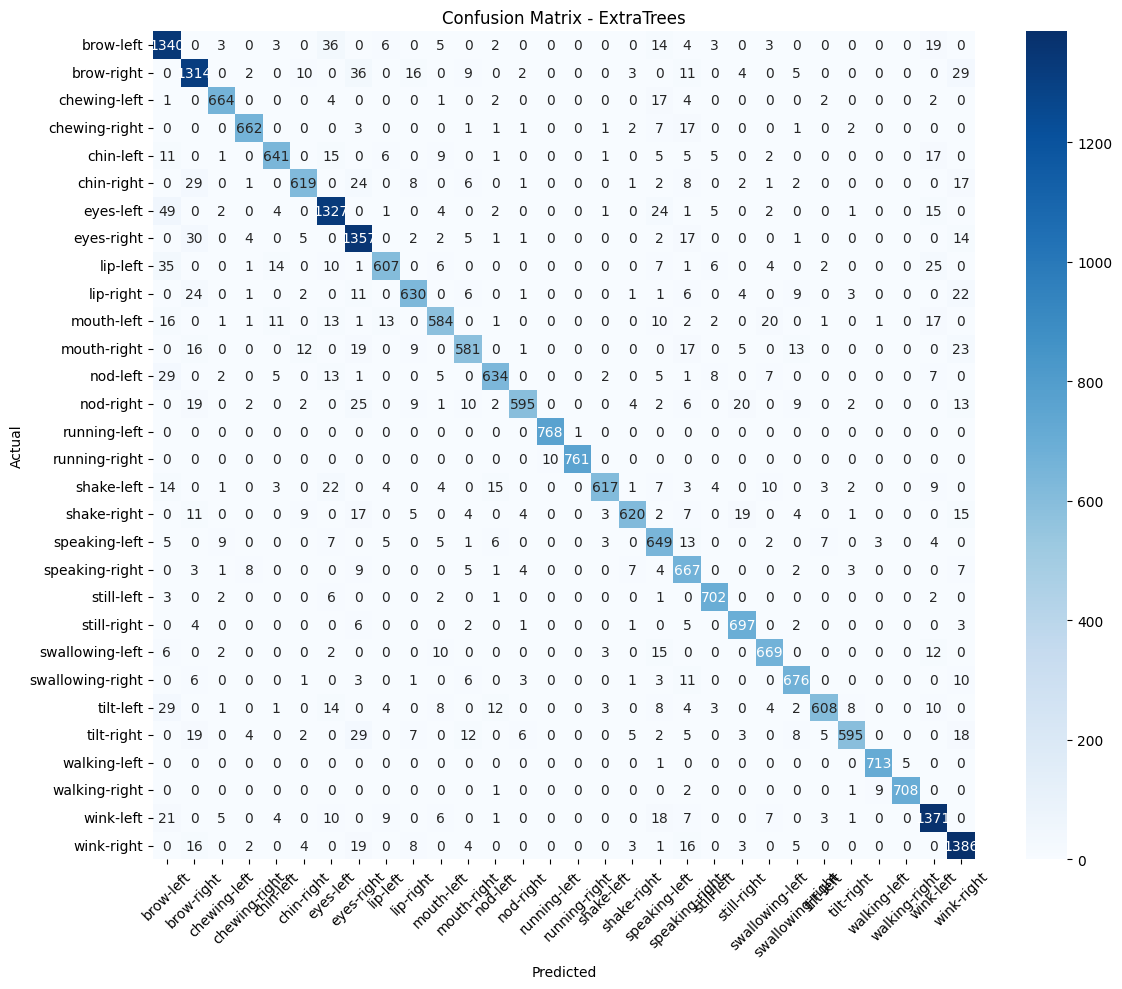

In [25]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_et)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix - ExtraTrees")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

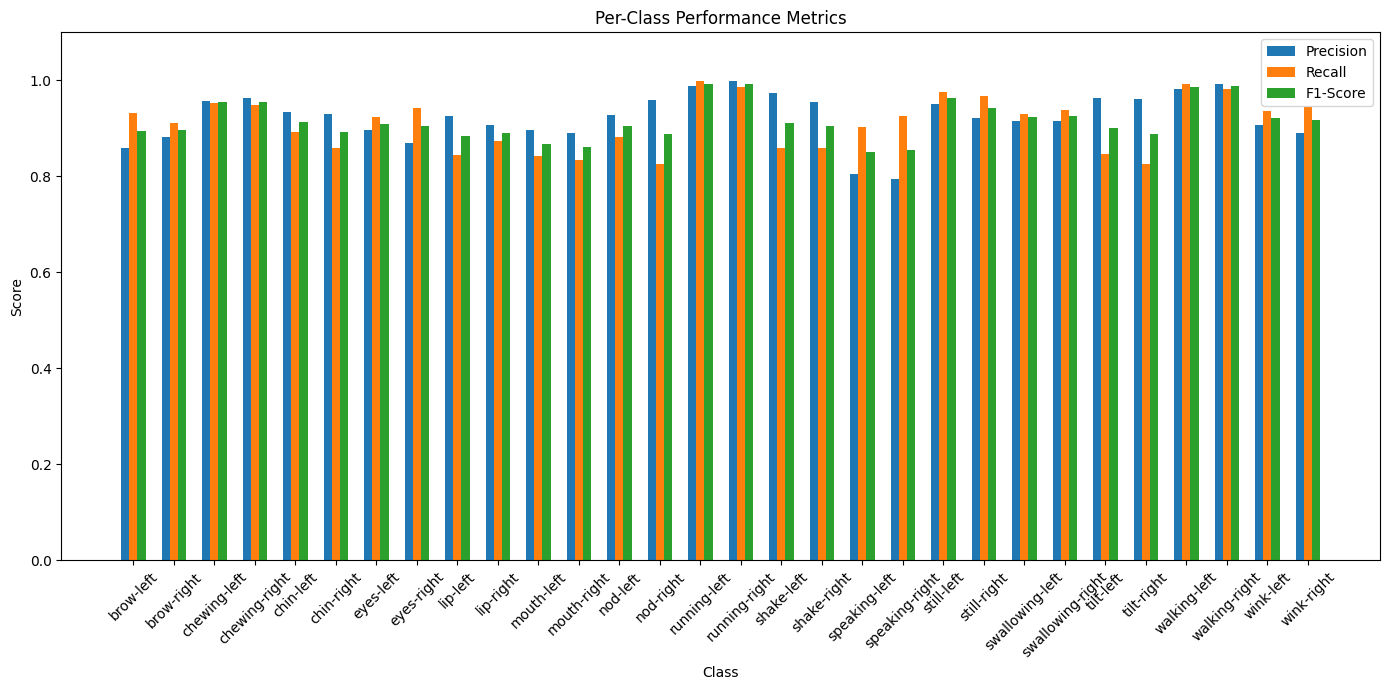

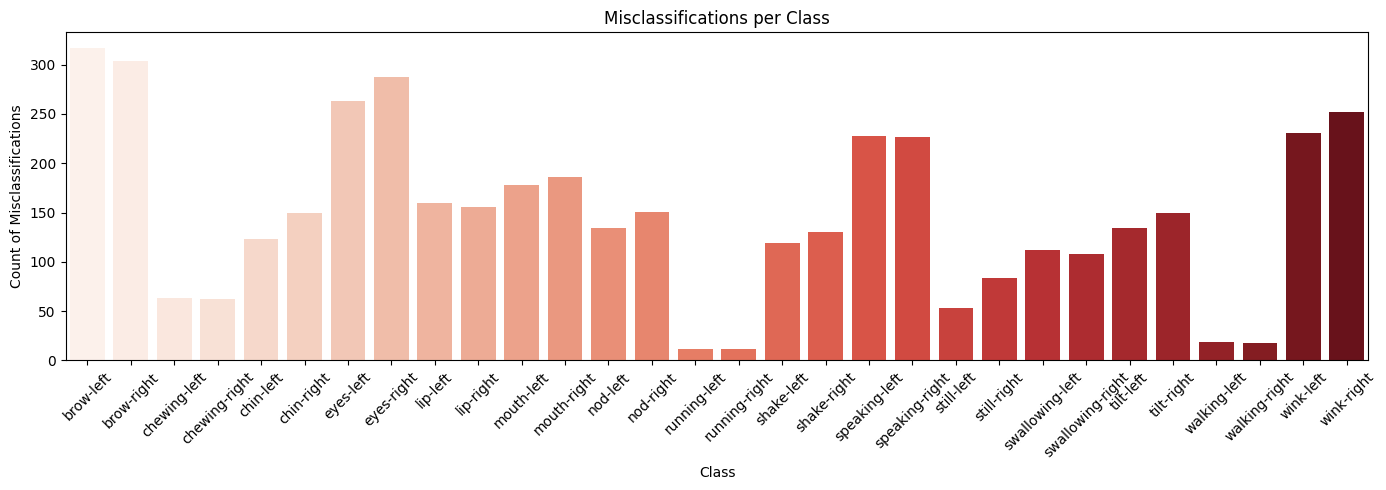

In [26]:
# Initialising lists to store the metrics
classes = le.classes_
precisions, recalls, f1_scores, misclassifications = [], [], [], []

for idx, label in enumerate(classes):
    true_positives = cm[idx, idx]
    false_negatives = cm[idx].sum() - true_positives
    false_positives = cm[:, idx].sum() - true_positives
    true_negatives = cm.sum() - (true_positives + false_negatives + false_positives)

    precision = true_positives / (true_positives + false_positives + 1e-10)
    recall = true_positives / (true_positives + false_negatives + 1e-10)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-10)
    misclassified = false_negatives + false_positives

    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)
    misclassifications.append(misclassified)

# Plotting grouped bar chart
x = np.arange(len(classes))
width = 0.2

plt.figure(figsize=(14, 7))
plt.bar(x - width, precisions, width=width, label='Precision')
plt.bar(x, recalls, width=width, label='Recall')
plt.bar(x + width, f1_scores, width=width, label='F1-Score')
plt.xticks(x, classes, rotation=45)
plt.title("Per-Class Performance Metrics")
plt.xlabel("Class")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.show()

# Plotting misclassifications separately
plt.figure(figsize=(14, 5))
sns.barplot(x=classes, y=misclassifications, palette='Reds')
plt.title("Misclassifications per Class")
plt.xlabel("Class")
plt.ylabel("Count of Misclassifications")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
# Person with highest accuracy
best_et_person = df_person_scores_et.loc[df_person_scores_et['Accuracy'].idxmax()]
print(f"Highest Accuracy for ExtraTrees: {best_et_person['Accuracy']:.2%} by Person {int(best_et_person['person_id'])}")

Highest Accuracy for ExtraTrees: 98.56% by Person 27


In [28]:
# Person with highest F1-score
best_et_person = df_person_scores_et.loc[df_person_scores_et['F1-Score'].idxmax()]
print(f"Highest F1-score: {best_et_person['F1-Score']:.2%} by Person {int(best_et_person['person_id'])}")

Highest F1-score: 98.72% by Person 27


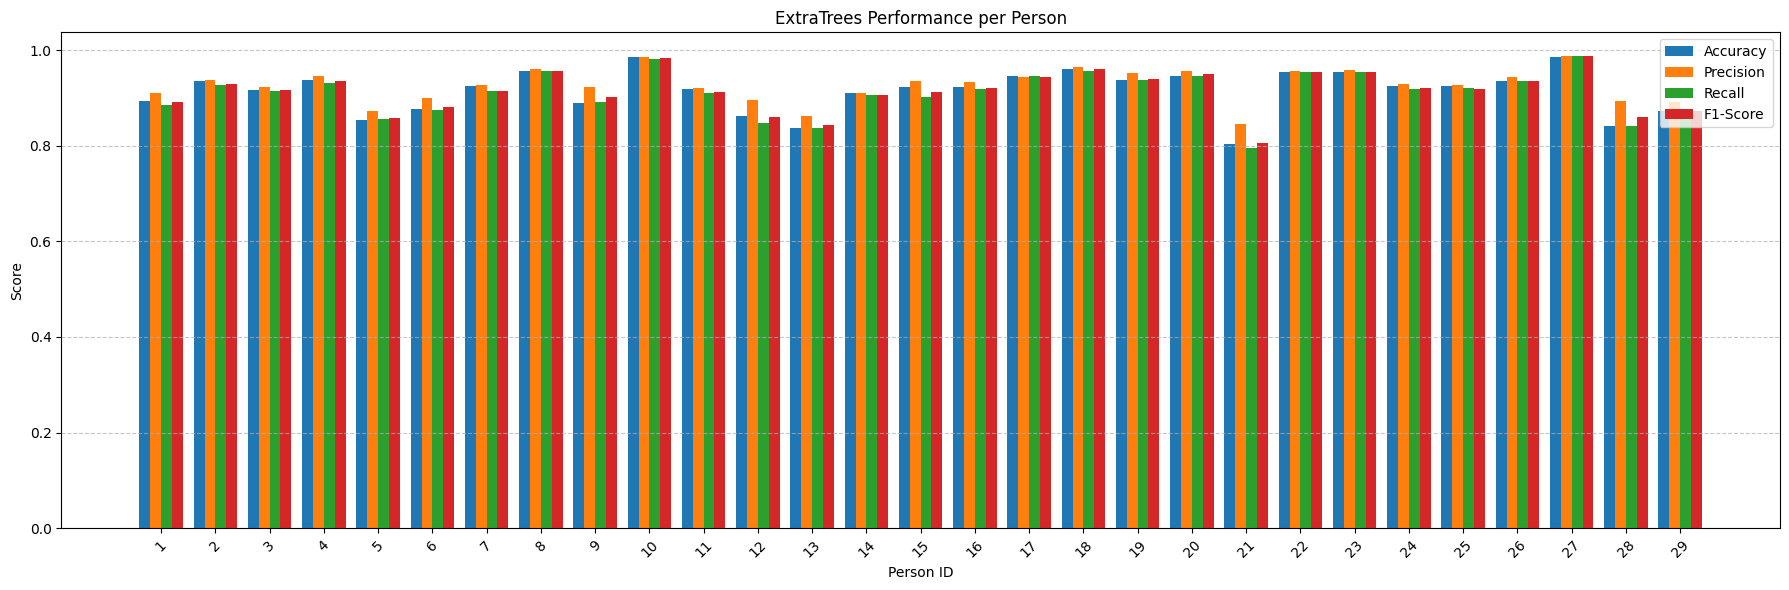

In [29]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(df_person_scores_et))
width = 0.2

plt.figure(figsize=(18, 6))
for i, metric in enumerate(metrics):
    plt.bar(x + i * width, df_person_scores_et[metric], width, label=metric)

plt.xticks(x + 1.5 * width, df_person_scores_et['person_id'].astype(str), rotation=45)
plt.xlabel("Person ID")
plt.ylabel("Score")
plt.title("ExtraTrees Performance per Person")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# **Random Forest Classifier**

In [30]:
# Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# Training the model
rf_model.fit(X_train, y_train)

# Per-person evaluation
person_scores_rf = []
unique_test_pids = np.unique(person_id_test)

for pid in unique_test_pids:
    mask = (person_id_test == pid)
    X_person = X_test[mask]
    y_person = y_test[mask]

    if len(y_person) == 0:
        continue

    y_pred_person = rf_model.predict(X_person)

    acc = accuracy_score(y_person, y_pred_person)
    prec = precision_score(y_person, y_pred_person, average='macro', zero_division=0)
    rec = recall_score(y_person, y_pred_person, average='macro', zero_division=0)
    f1 = f1_score(y_person, y_pred_person, average='macro', zero_division=0)

    person_scores_rf.append({
        'person_id': pid,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

df_person_scores_rf = pd.DataFrame(person_scores_rf)

# Evaluation
rf_preds = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)
print(f"Random Forest Accuracy: {rf_acc * 100:.2f}%")
print(classification_report(y_test, rf_preds, target_names=le.classes_))

Random Forest Accuracy: 89.88%
                  precision    recall  f1-score   support

       brow-left       0.85      0.92      0.88      1438
      brow-right       0.85      0.89      0.87      1441
    chewing-left       0.94      0.93      0.93       697
   chewing-right       0.95      0.94      0.95       698
       chin-left       0.92      0.88      0.90       719
      chin-right       0.92      0.83      0.87       721
       eyes-left       0.89      0.91      0.90      1438
      eyes-right       0.86      0.93      0.90      1441
        lip-left       0.90      0.83      0.87       719
       lip-right       0.89      0.83      0.86       721
      mouth-left       0.85      0.80      0.83       694
     mouth-right       0.86      0.80      0.83       696
        nod-left       0.92      0.86      0.89       719
       nod-right       0.93      0.81      0.86       721
    running-left       0.99      1.00      0.99       769
   running-right       1.00      0.99   

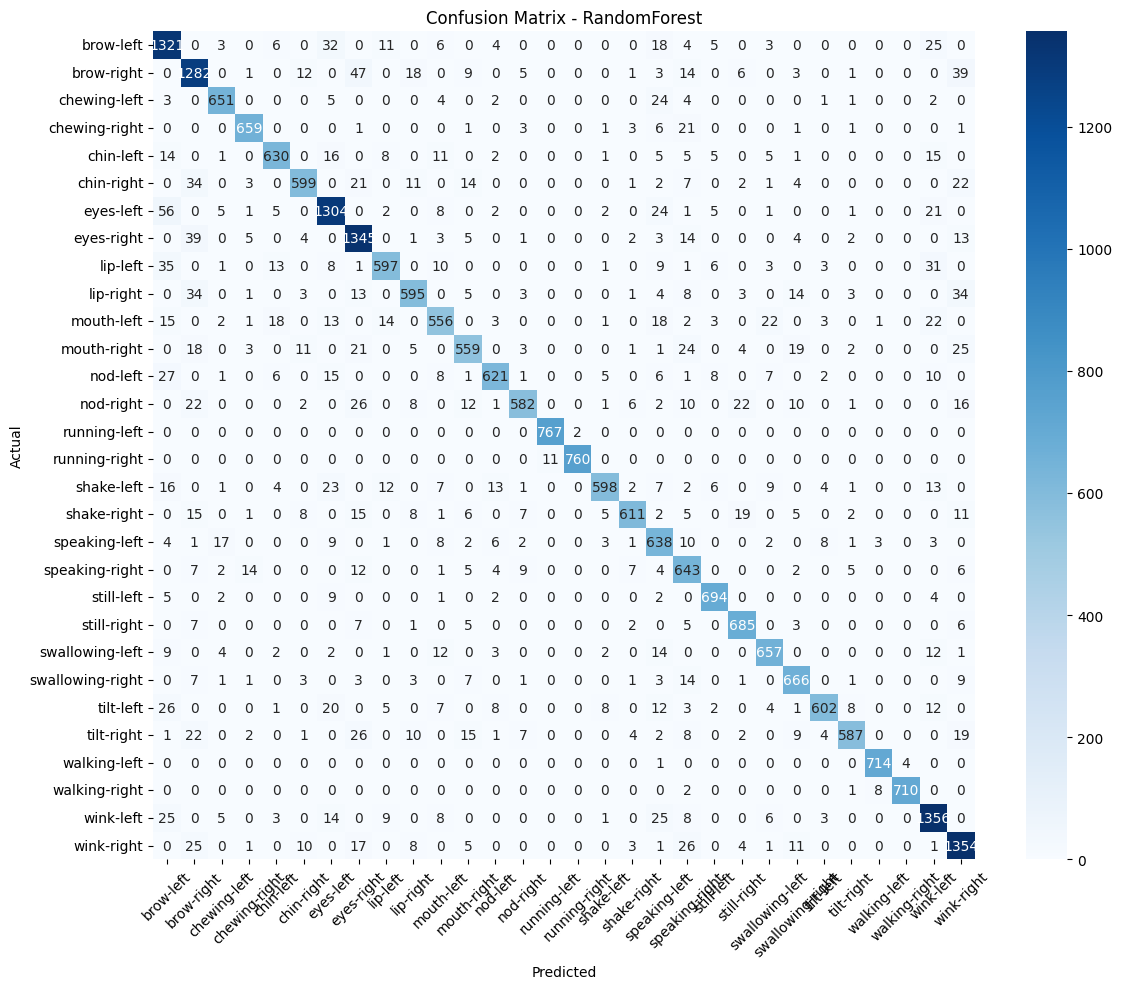

In [32]:
# Confusion Matrix
cm = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix - RandomForest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

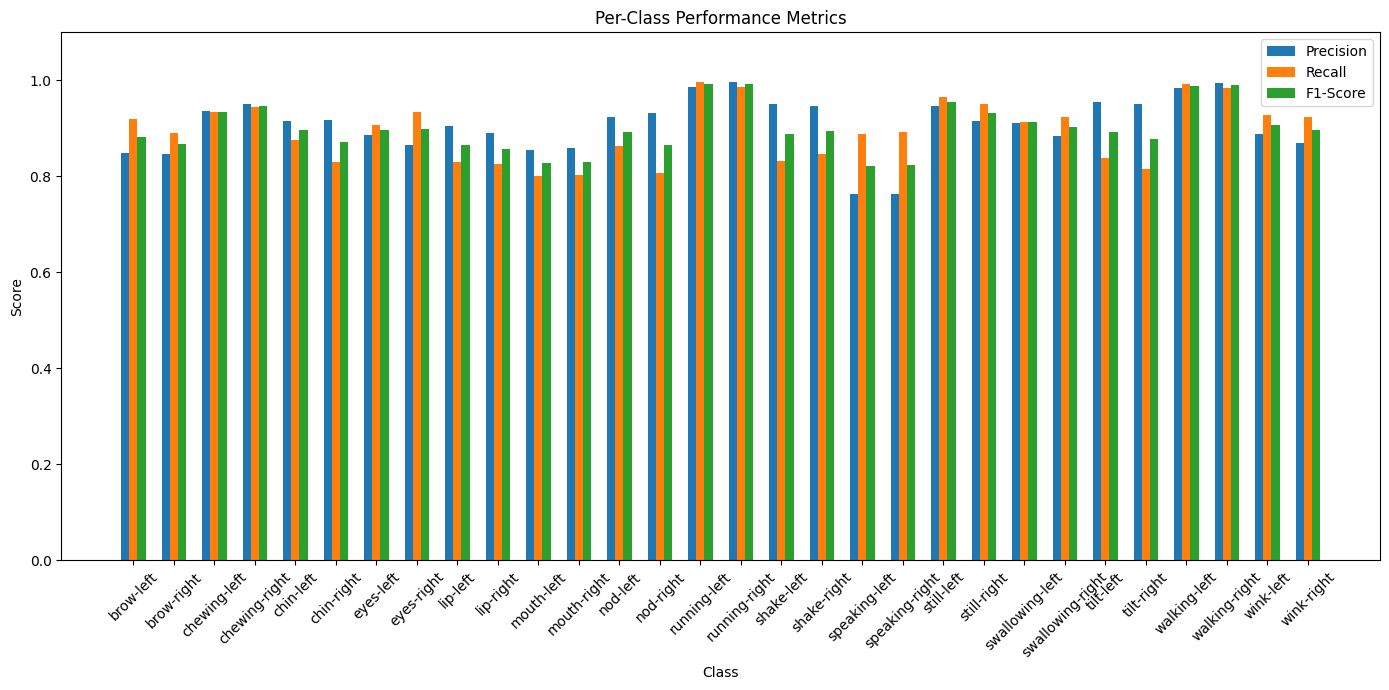

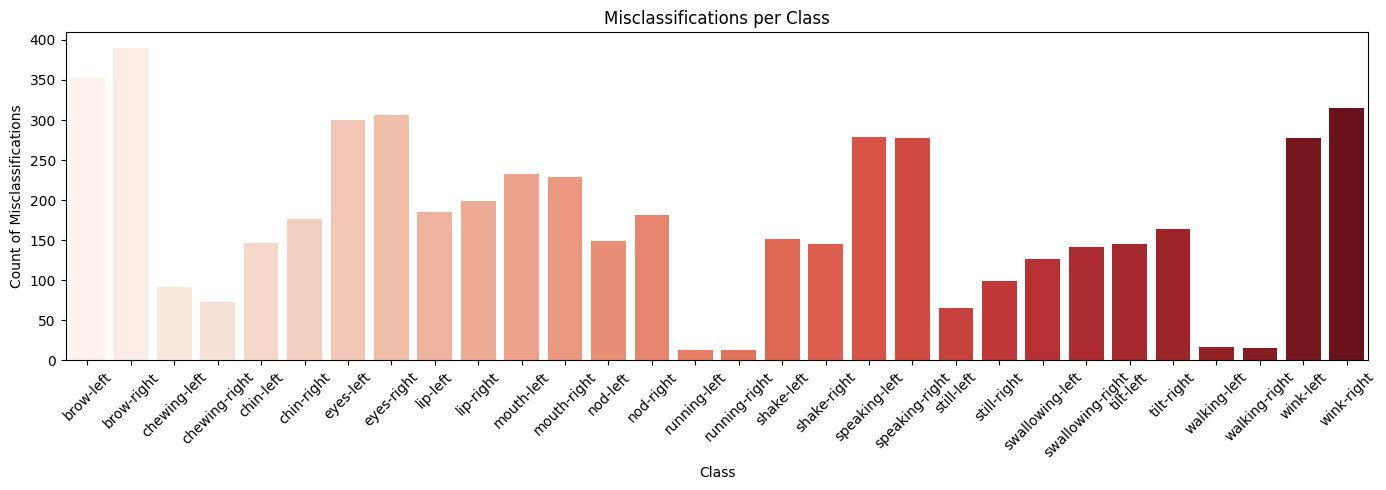

In [33]:
# Initialising lists to store the metrics
classes = le.classes_
precisions, recalls, f1_scores, misclassifications = [], [], [], []

for idx, label in enumerate(classes):
    true_positives = cm[idx, idx]
    false_negatives = cm[idx].sum() - true_positives
    false_positives = cm[:, idx].sum() - true_positives
    true_negatives = cm.sum() - (true_positives + false_negatives + false_positives)

    precision = true_positives / (true_positives + false_positives + 1e-10)
    recall = true_positives / (true_positives + false_negatives + 1e-10)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-10)
    misclassified = false_negatives + false_positives

    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)
    misclassifications.append(misclassified)

# Plotting grouped bar chart
x = np.arange(len(classes))
width = 0.2

plt.figure(figsize=(14, 7))
plt.bar(x - width, precisions, width=width, label='Precision')
plt.bar(x, recalls, width=width, label='Recall')
plt.bar(x + width, f1_scores, width=width, label='F1-Score')
plt.xticks(x, classes, rotation=45)
plt.title("Per-Class Performance Metrics")
plt.xlabel("Class")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.show()

# Plotting misclassifications separately
plt.figure(figsize=(14, 5))
sns.barplot(x=classes, y=misclassifications, palette='Reds')
plt.title("Misclassifications per Class")
plt.xlabel("Class")
plt.ylabel("Count of Misclassifications")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [34]:
# Person with highest accuracy
best_rf_person = df_person_scores_rf.loc[df_person_scores_rf['Accuracy'].idxmax()]
print(f"Highest Accuracy for Random Forest: {best_rf_person['Accuracy']:.2%} by Person {int(best_rf_person['person_id'])}")

Highest Accuracy for Random Forest: 97.67% by Person 10


In [35]:
# Person with highest F1 score
best_rf_person = df_person_scores_rf.loc[df_person_scores_rf['F1-Score'].idxmax()]
print(f"Highest F1-score for Random Forest: {best_rf_person['F1-Score']:.2%} by Person {int(best_rf_person['person_id'])}")

Highest F1-score for Random Forest: 97.42% by Person 10


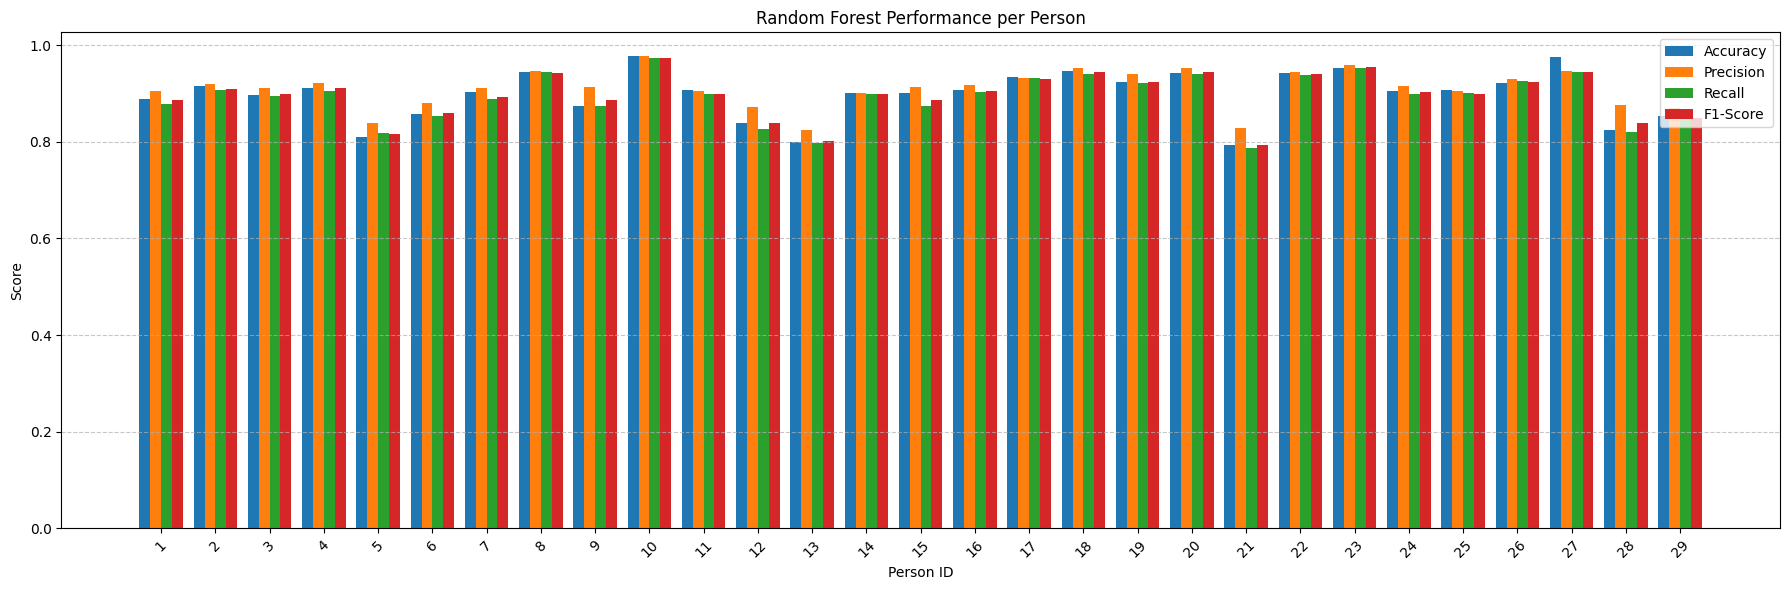

In [36]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(df_person_scores_rf))
width = 0.2

plt.figure(figsize=(18, 6))
for i, metric in enumerate(metrics):
    plt.bar(x + i * width, df_person_scores_rf[metric], width, label=metric)

plt.xticks(x + 1.5 * width, df_person_scores_rf['person_id'].astype(str), rotation=45)
plt.xlabel("Person ID")
plt.ylabel("Score")
plt.title("Random Forest Performance per Person")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# **Voting Classifier**

In [7]:
# Defining individual models
model_lgb = LGBMClassifier(
    objective='multiclass',
    num_class=len(le.classes_),
    learning_rate=0.05,
    num_leaves=64,
    max_depth=-1,
    random_state=42,
    n_estimators=1000
)
model_xgb = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=len(le.classes_),
    max_depth=10,
    learning_rate=0.1,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)
model_et = ExtraTreesClassifier(n_estimators=400, random_state=42)

# Voting Classifier (soft voting)
voting_clf = VotingClassifier(
    estimators=[
        ('lgb', model_lgb),
        ('xgb', model_xgb),
        ('et', model_et)
    ],
    voting='soft',
    weights=[4, 2, 1]  # More weight to LGBM
)
# Training
voting_clf.fit(X_train, y_train)

# Per-person evaluation
person_scores_vote = []
unique_test_pids = np.unique(person_id_test)

for pid in unique_test_pids:
    mask = (person_id_test == pid)
    X_person = X_test[mask]
    y_person = y_test[mask]

    if len(y_person) == 0:
        continue

    y_pred_person = voting_clf.predict(X_person)

    acc = accuracy_score(y_person, y_pred_person)
    prec = precision_score(y_person, y_pred_person, average='macro', zero_division=0)
    rec = recall_score(y_person, y_pred_person, average='macro', zero_division=0)
    f1 = f1_score(y_person, y_pred_person, average='macro', zero_division=0)

    person_scores_vote.append({
        'person_id': pid,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

df_person_scores_vote = pd.DataFrame(person_scores_vote)

# Evaluation
y_pred = voting_clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Voting Classifier Accuracy: {acc * 100:.2f}%")
print(classification_report(y_test, y_pred, target_names=le.classes_))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.129300 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 31548
[LightGBM] [Info] Number of data points in the train set: 103887, number of used features: 158
[LightGBM] [Info] Start training from score -2.893409
[LightGBM] [Info] Start training from score -2.891499
[LightGBM] [Info] Start training from score -3.618338
[LightGBM] [Info] Start training from score -3.615830
[LightGBM] [Info] Start training from score -3.586556
[LightGBM] [Info] Start training from score -3.584819
[LightGBM] [Info] Start training from score -2.893409
[LightGBM] [Info] Start training from score -2.891499
[LightGBM] [Info] Start training from score -3.586556
[LightGBM] [Info] Start training from score -3.584819
[LightGBM] [Info] Start training from score -3.621573
[LightGBM] [Info] Start training from score -3.619774
[LightGBM] [Info] Start training from score -3.586556
[Light

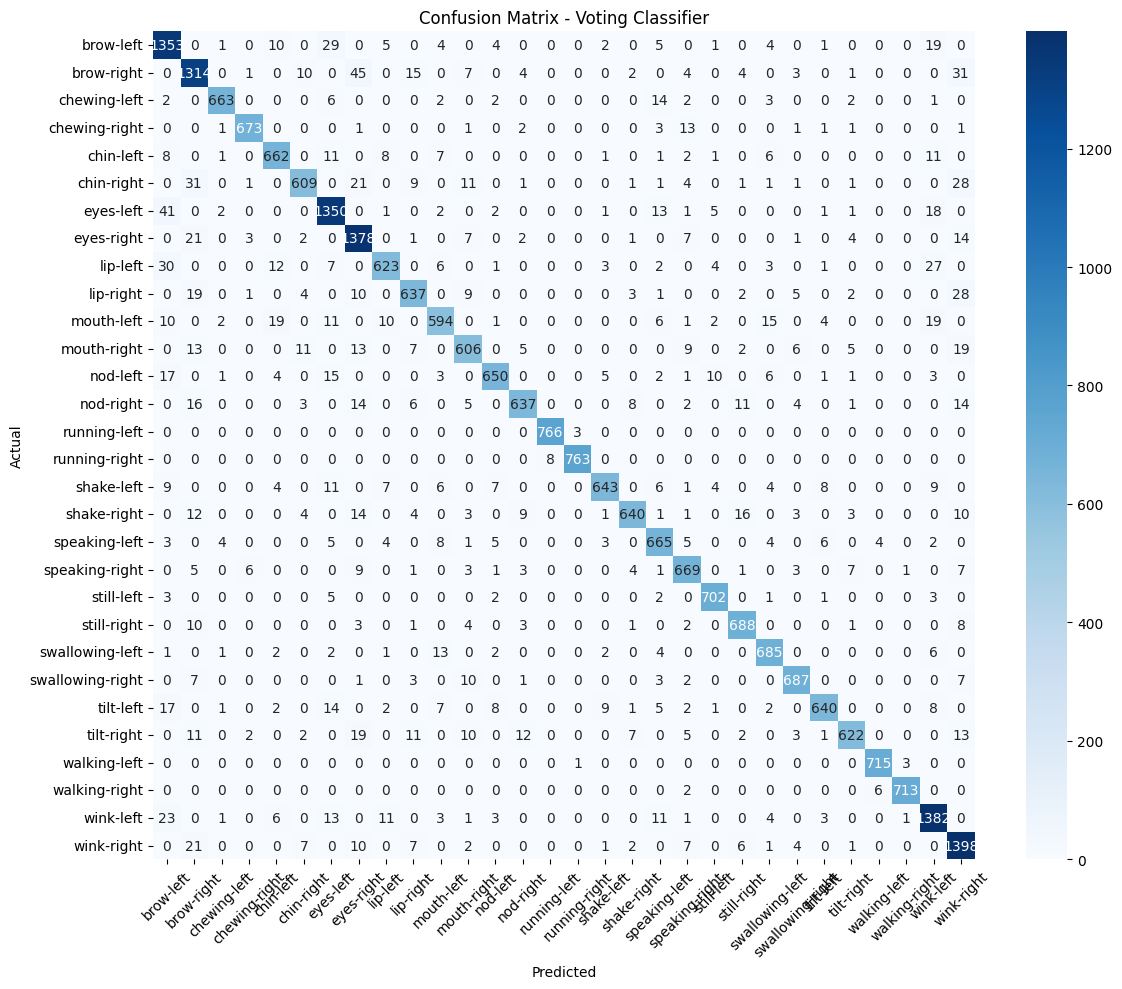

In [13]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix - Voting Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

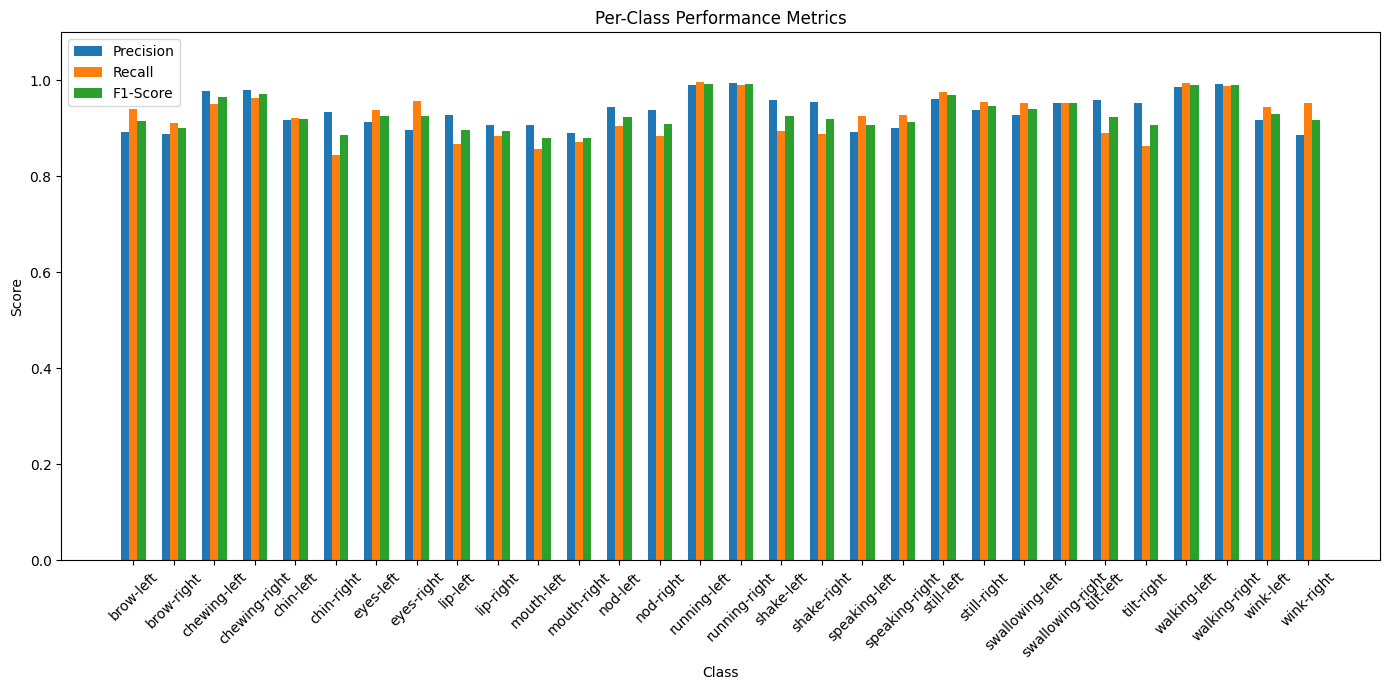

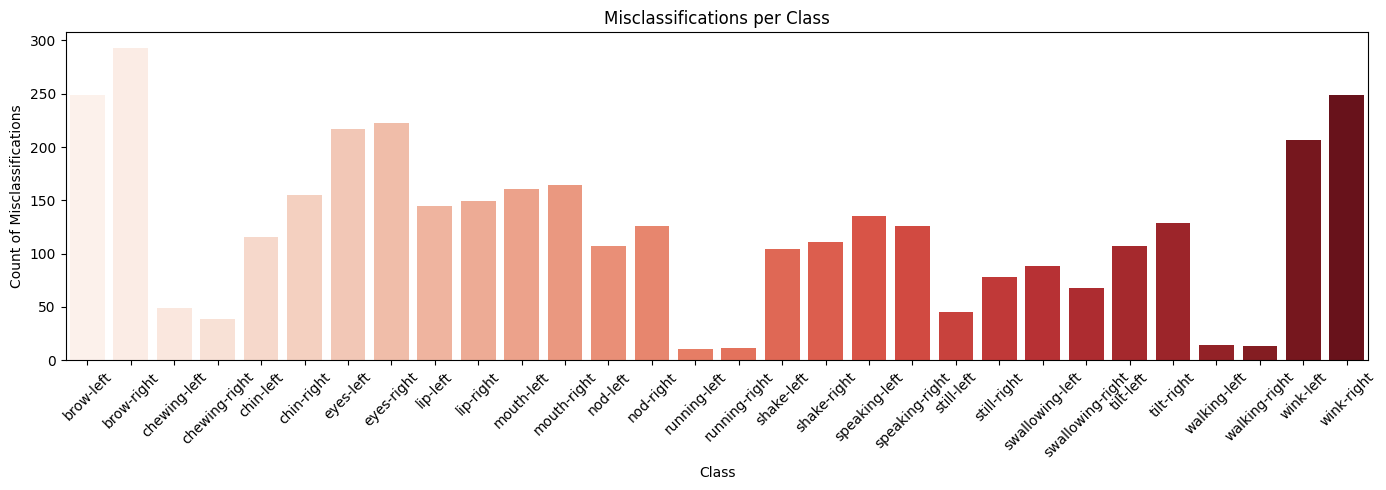

In [14]:
# Initialising lists to store the metrics
classes = le.classes_
precisions, recalls, f1_scores, misclassifications = [], [], [], []

for idx, label in enumerate(classes):
    true_positives = cm[idx, idx]
    false_negatives = cm[idx].sum() - true_positives
    false_positives = cm[:, idx].sum() - true_positives
    true_negatives = cm.sum() - (true_positives + false_negatives + false_positives)

    precision = true_positives / (true_positives + false_positives + 1e-10)
    recall = true_positives / (true_positives + false_negatives + 1e-10)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-10)
    misclassified = false_negatives + false_positives

    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)
    misclassifications.append(misclassified)

# Plotting grouped bar chart
x = np.arange(len(classes))
width = 0.2

plt.figure(figsize=(14, 7))
plt.bar(x - width, precisions, width=width, label='Precision')
plt.bar(x, recalls, width=width, label='Recall')
plt.bar(x + width, f1_scores, width=width, label='F1-Score')
plt.xticks(x, classes, rotation=45)
plt.title("Per-Class Performance Metrics")
plt.xlabel("Class")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.show()

# Plotting misclassifications separately
plt.figure(figsize=(14, 5))
sns.barplot(x=classes, y=misclassifications, palette='Reds')
plt.title("Misclassifications per Class")
plt.xlabel("Class")
plt.ylabel("Count of Misclassifications")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
# Person with highest accuracy
best_vote_person = df_person_scores_vote.loc[df_person_scores_vote['Accuracy'].idxmax()]
print(f"Highest Accuracy for Voting Classifier: {best_vote_person['Accuracy']:.2%} by Person ID: {int(best_vote_person['person_id'])}")

Highest Accuracy for Voting Classifier: 98.78% by Person ID: 27


In [16]:
# Person with highest F1-score
best_vote_person = df_person_scores_vote.loc[df_person_scores_vote['F1-Score'].idxmax()]
print(f"Highest F1-score for Voting Classifier: {best_vote_person['F1-Score']:.2%} by Person {int(best_vote_person['person_id'])}")

Highest F1-score for Voting Classifier: 98.95% by Person 27


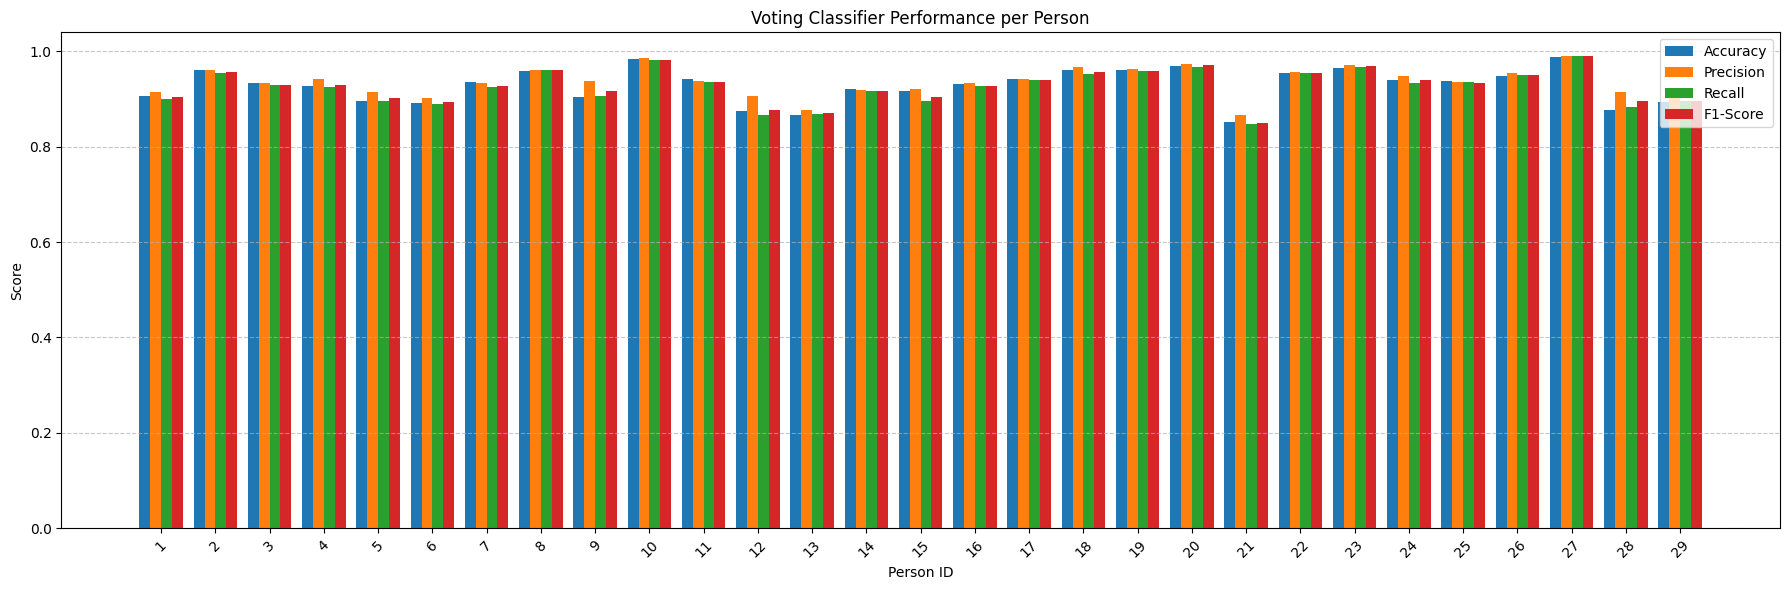

In [17]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(df_person_scores_vote))
width = 0.2

plt.figure(figsize=(18, 6))
for i, metric in enumerate(metrics):
    plt.bar(x + i * width, df_person_scores_vote[metric], width, label=metric)

plt.xticks(x + 1.5 * width, df_person_scores_vote['person_id'].astype(str), rotation=45)
plt.xlabel("Person ID")
plt.ylabel("Score")
plt.title("Voting Classifier Performance per Person")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# **Cross-Validation on the best model- *Voting Classifier***


3-Fold CV Accuracies: [0.92004528 0.91923486 0.9196738 ]
Mean Accuracy: 0.9197
Standard Deviation: 0.0003


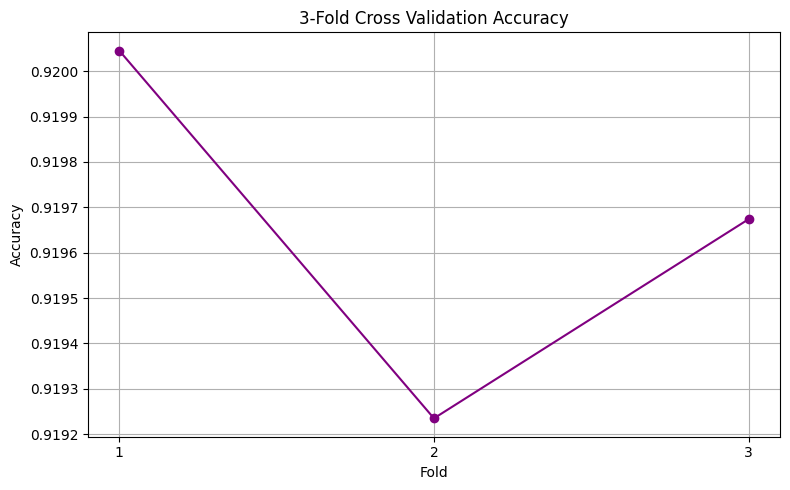

In [7]:
# K-Fold Cross Validation (Stratified)
k = 3
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

cv_scores = cross_val_score(voting_clf, X, y, cv=skf, scoring='accuracy', n_jobs=-1)

# Printing & Plotting CV Results
print(f"\n{ k }-Fold CV Accuracies:", cv_scores)
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

plt.figure(figsize=(8, 5))
plt.plot(range(1, k + 1), cv_scores, marker='o', linestyle='-', color='purple')
plt.title(f'{k}-Fold Cross Validation Accuracy')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.xticks(range(1, k + 1))
plt.grid(True)
plt.tight_layout()
plt.show()

# **Hyper-parameter Tuning: Comparing Performances across different *(window size, step size)* values**

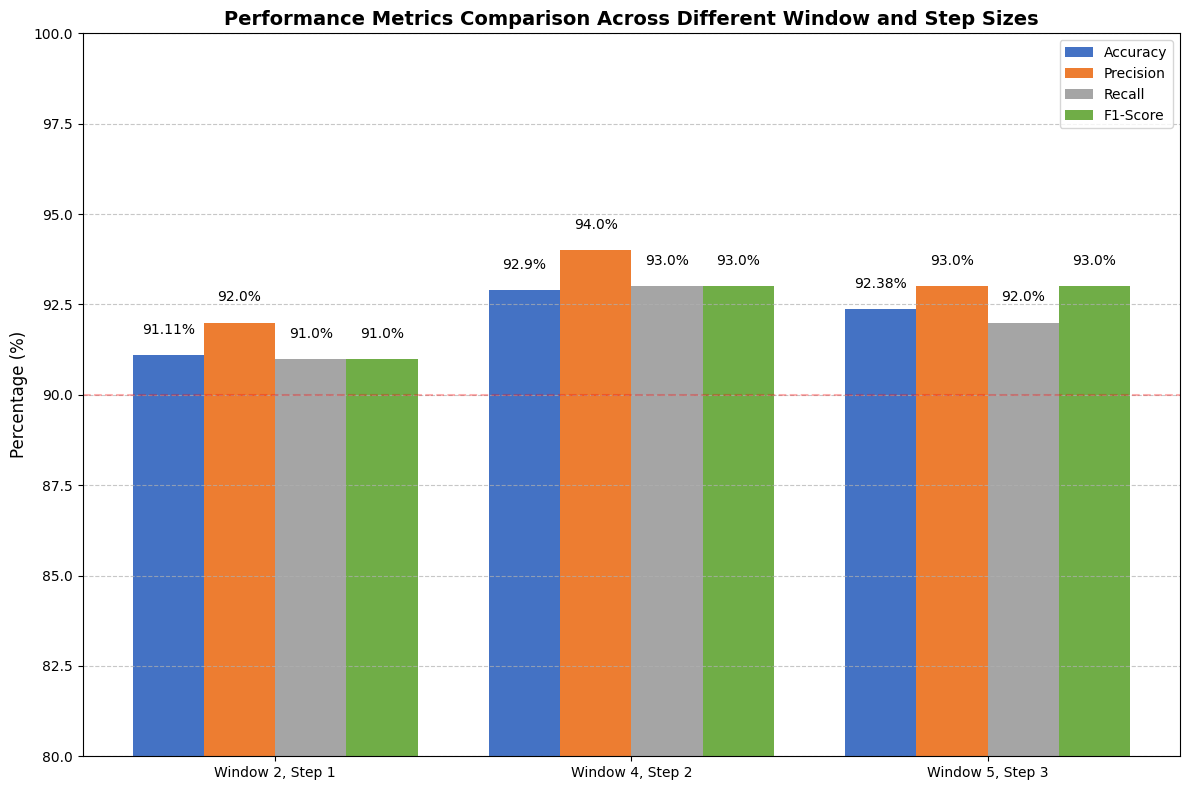

In [3]:
# Metrics acheived in three pipelines in the three Jupyter Notebooks 
metrics = {
    'Window 2, Step 1': {
        'Accuracy': 91.11,
        'Precision': 92,  
        'Recall': 91,     
        'F1-Score': 91    
    },
    'Window 4, Step 2': {
        'Accuracy': 92.90,
        'Precision': 94,
        'Recall': 93,
        'F1-Score': 93
    },
    'Window 5, Step 3': {
        'Accuracy': 92.38,
        'Precision': 93,
        'Recall': 92,
        'F1-Score': 93
    }
}

# Converting to DataFrame for easier plotting
df = pd.DataFrame(metrics).T

fig, ax = plt.subplots(figsize=(12, 8))
bar_width = 0.2
x = np.arange(len(df.index))

# Creating bars for each metric
ax.bar(x - bar_width*1.5, df['Accuracy'], width=bar_width, label='Accuracy', color='#4472C4')
ax.bar(x - bar_width*0.5, df['Precision'], width=bar_width, label='Precision', color='#ED7D31')
ax.bar(x + bar_width*0.5, df['Recall'], width=bar_width, label='Recall', color='#A5A5A5')
ax.bar(x + bar_width*1.5, df['F1-Score'], width=bar_width, label='F1-Score', color='#70AD47')

# Adding text annotations above bars
for i, j in enumerate(x):
    ax.text(j - bar_width*1.5, df['Accuracy'][i] + 0.5, f"{df['Accuracy'][i]}%", ha='center', va='bottom')
    ax.text(j - bar_width*0.5, df['Precision'][i] + 0.5, f"{df['Precision'][i]}%", ha='center', va='bottom')
    ax.text(j + bar_width*0.5, df['Recall'][i] + 0.5, f"{df['Recall'][i]}%", ha='center', va='bottom')
    ax.text(j + bar_width*1.5, df['F1-Score'][i] + 0.5, f"{df['F1-Score'][i]}%", ha='center', va='bottom')

# Customising the plot
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Performance Metrics Comparison Across Different Window and Step Sizes', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df.index, fontsize=10)
ax.legend(fontsize=10)
ax.set_ylim(80, 100)  # Setting y-axis limits for better visualisation
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Adding a horizontal line for visual reference at 90%
ax.axhline(y=90, color='red', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# **Comparing Performances of the Different Models**

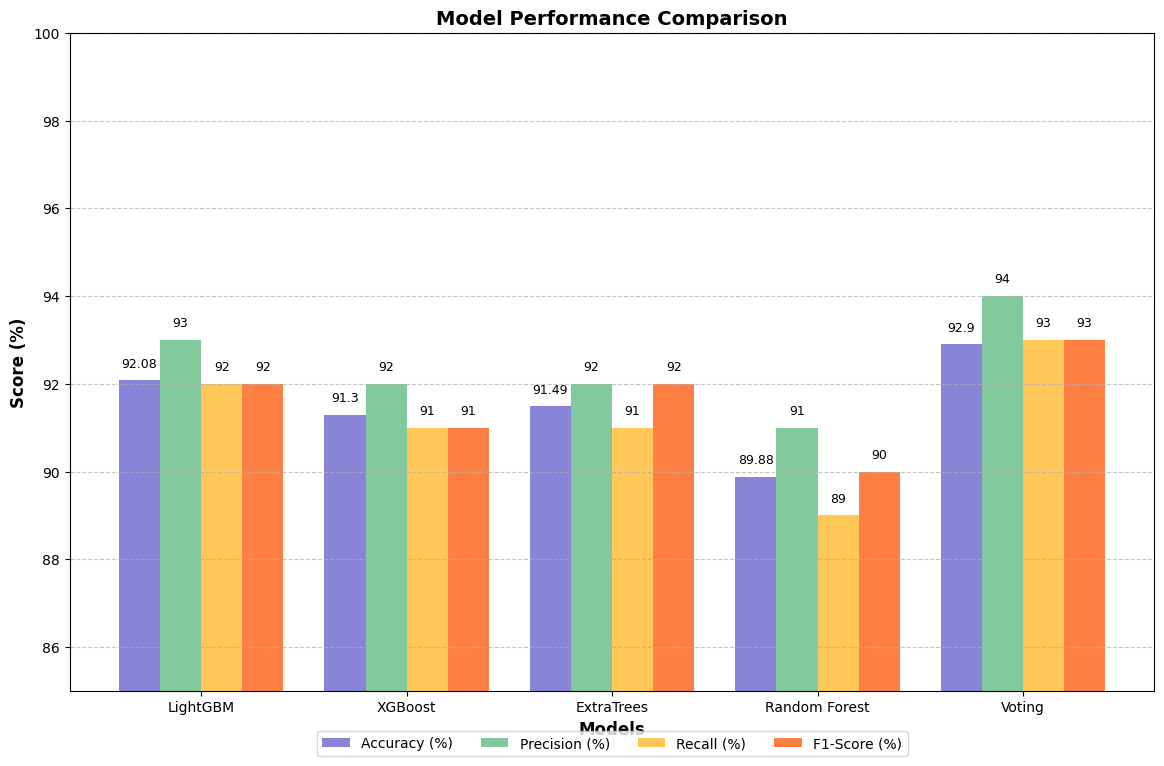

In [2]:
models = ['LightGBM', 'XGBoost', 'ExtraTrees', 'Random Forest', 'Voting']

# Model accuracy values from above
accuracy = [92.08, 91.30, 91.49, 89.88, 92.90]

# Macro average values for precision, recall, and F1 scores from above
precision = [93, 92, 92, 91, 94]
recall = [92, 91, 91, 89, 93]
f1_score = [92, 91, 92, 90, 93]

barWidth = 0.2
r1 = np.arange(len(models))
r2 = [x + barWidth for x in r1]
r3 = [x + barWidth for x in r2]
r4 = [x + barWidth for x in r3]

# Creating the plot
plt.figure(figsize=(12, 8))

# Creating bars
plt.bar(r1, accuracy, width=barWidth, label='Accuracy (%)', color='#8884d8')
plt.bar(r2, precision, width=barWidth, label='Precision (%)', color='#82ca9d')
plt.bar(r3, recall, width=barWidth, label='Recall (%)', color='#ffc658')
plt.bar(r4, f1_score, width=barWidth, label='F1-Score (%)', color='#ff8042')

# Adding labels and title
plt.xlabel('Models', fontweight='bold', fontsize=12)
plt.ylabel('Score (%)', fontweight='bold', fontsize=12)
plt.title('Model Performance Comparison', fontweight='bold', fontsize=14)
plt.xticks([r + 1.5 * barWidth for r in range(len(models))], models)

# Setting y-axis to start from 85 for better visualisation of differences
plt.ylim(85, 100)

# Adding grid lines for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adding legend
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=4)

# Adding value labels on top of each bar
for i, bars in enumerate([r1, r2, r3, r4]):
    values = [accuracy, precision, recall, f1_score][i]
    for j, bar in enumerate(bars):
        plt.text(bar, values[j] + 0.3, str(values[j]), ha='center', fontsize=9)

plt.tight_layout(pad=2.0)

# Displaying the chart
plt.show()